# **Facial Emotion Detection**

## **Problem Definition**

**The context:** *Why is this problem important to solve?*<br>

*   A large portion of human sentiment is communicated non-verbally, especially through facial expressions and visual cues.
*   For human–machine interaction, machines that can infer emotion can respond more appropriately (tone, assistance, escalation), making interactions feel more natural and effective.
* Facial emotion recognition is a core capability within Affective Computing / Emotion AI, which aims to enable systems to interpret human emotional signals (face, voice, gestures) and act accordingly.
* Practical value shows up in many domains:
    * Customer-facing assistants (better service, sentiment-aware routing/escalation)
    * Human behavior understanding (education, training, usability research)
    * Mental health / disorder screening support (as an assistive signal, not a diagnosis)
    * Safety monitoring (fatigue/stress indicators in controlled settings)

**The objectives:** *What is the intended goal?*<br>

* Build a deep learning computer vision model (CNN-based) that can:
    * Take a face image as input
    * Predict the emotion class (multi-class classification)
    * Achieve strong performance on unseen images (generalization)
* Produce a model that is not only accurate, but also robust to real-world variation (lighting, pose, occlusion, demographics, camera quality), within the limits of the dataset.

**The key questions:** *What are the key questions that need to be answered?*<br>

1. Data & Labels
    * What emotion categories exist (e.g., angry, happy, sad, fear, surprise, neutral, disgust)?
    * Is the dataset balanced, and how noisy are the labels?
2. Preprocessing
    * Can the model detect/align faces first, or assume faces are already cropped?
    * What input size and normalization strategy works best?
3. Modeling
    * Which CNN architecture performs best given dataset size (custom CNN vs transfer learning)?
    * What regularization (dropout, augmentation, weight decay) improves generalization?
4. Evaluation
    * What metrics matter most: accuracy, macro-F1, confusion matrix, per-class recall?
    * Where does the model fail (which emotions get confused, and why)?
5. Deployment readiness
    * Is inference fast enough for the intended use (real-time vs batch)?
    * How do we handle uncertainty (low confidence predictions)?
6. Ethichs & risk
    * Are there demographic performance gaps?
    * What are appropriate usage boundaries (avoid overstating “emotion reading” as ground truth)?


**The problem formulation:** *What are we trying to solve using data science?*

*   Supervised multi-class image classification
    * Input (X): facial images (possibly pre-cropped/aligned)
    * Target (y): one of K emotion classes
    * Model: CNN (or transfer-learning backbone) trained to learn features from images
    * Objective function: minimize multi-class classification loss (typically cross-entropy)
    * Outcome: predicted emotion label + probability distribution over classes



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile

# For Data Visualization
import seaborn as sns
import cv2

# For Model Building
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential, Model # Sequential API for sequential model
from tensorflow.keras.layers import Dense, Dropout, Flatten # Importing different layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Input, LeakyReLU, Activation
from tensorflow.keras import backend
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical # To perform one-hot encoding
from tensorflow.keras.optimizers import RMSprop, Adam, SGD # Optimizers for optimizing the model
from tensorflow.keras.callbacks import EarlyStopping  # Regularization method to prevent the overfitting
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import losses, optimizers
from tensorflow.keras.preprocessing.image import load_img
from google.colab.patches import cv2_imshow

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [3]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/Colab Notebooks/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

### **Setup paths + constants**

In [4]:
DATASET_DIR = "/content/Facial_emotion_images"
TRAIN_DIR = f"{DATASET_DIR}/train"
VAL_DIR   = f"{DATASET_DIR}/validation"
TEST_DIR  = f"{DATASET_DIR}/test"

IMG_SIZE = (48, 48)   # or (64,64), (96,96), etc.
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",              # integer labels for sparse_categorical_crossentropy
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Classes: ['happy', 'neutral', 'sad', 'surprise']


**This automatically:**



*   uses subfolder names as classes (the 4 emotions)
*   assigns stable integer labels (e.g., happy=0, neutral=1, … based on alphabetical folder order)
* resizes images for you



In [6]:
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = train_ds_raw.class_names  # <-- capture here
print("Class names:", class_names)

# Now do the pipeline transforms
normalization = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().prefetch(AUTOTUNE)

Found 15109 files belonging to 4 classes.
Class names: ['happy', 'neutral', 'sad', 'surprise']


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augmentation")

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

In [8]:
def show_single_class(ds, class_names, target, n=8):
    """
    ds: tf.data.Dataset yielding (images, labels)
    class_names: list of class names in label-index order
    target: int (class index) OR str (class name)
    n: number of images to display
    """
    # Resolve target class index + label
    if isinstance(target, int):
        target_idx = target
        target_name = class_names[target_idx]
    else:
        target_name = str(target)
        target_idx = class_names.index(target_name)

    imgs = []

    for images, labels in ds:
        for img, lab in zip(images, labels):
            if int(lab) == target_idx:
                imgs.append(img.numpy().astype("uint8"))
                if len(imgs) == n:
                    break
        if len(imgs) == n:
            break

    if len(imgs) == 0:
        print(f"No images found for class {target_idx} ({target_name}).")
        return

    plt.figure(figsize=(2*n, 2.5))
    for i in range(len(imgs)):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(imgs[i])
        plt.axis("off")

    plt.suptitle(f"Class {target_idx}: {target_name}", y=1.05, fontsize=14)
    plt.show()

### **Happy**

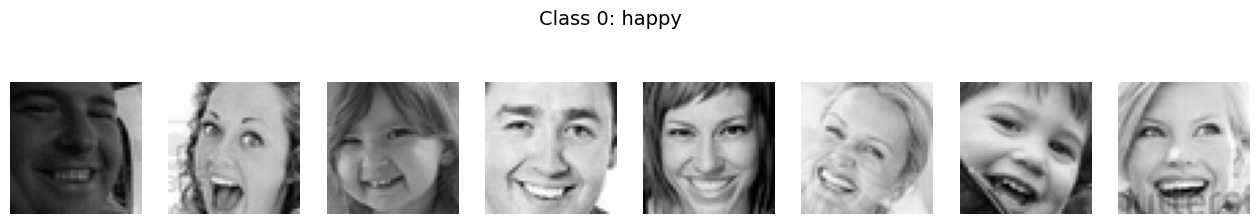

In [ ]:
show_single_class(train_ds_raw, class_names, "happy", n=8)

**Observations and Insights:**

Common visual cues:


*   Mouth corners pulled upward (smile), often showing teeth
*   Cheeks raised
*   “Crow’s feet”/wrinkles near outer eyes for genuine smiles
*   Eyes can look slightly narrower due to cheek lift


What separates expression:


*   The upward mouth curvature + cheek raise combination is usually the strongest separator vs neutral/sad.








### **Sad**

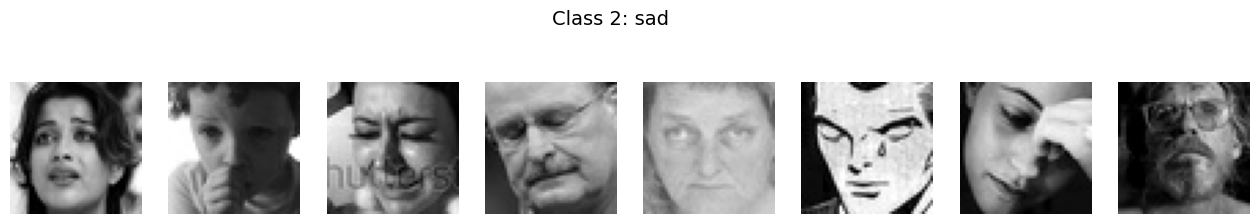

In [ ]:
show_single_class(train_ds_raw, class_names, "sad", n=8)

**Observations and Insights:**

Common visual cues:


*   Mouth corners pulled downward or lips pressed lightly
*   Eyebrows tilted upward in the center (inner brow raise) → “puppy eyes” effect
*   Eyes may appear droopy, gaze downward
*   Face often looks less “activated” than surprise


What separates expression:


*   The inner eyebrow raise + downturned mouth is a distinctive pattern compared with neutral.






### **Neutral**

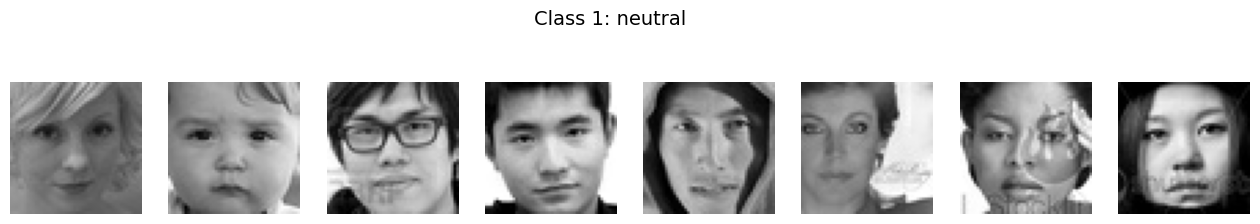

In [ ]:
show_single_class(train_ds_raw, class_names, "neutral", n=8)

**Observations and Insights:**

Common visual cues:


*   Relaxed facial muscles
*   Closed mouth with minimal curvature
*   Eyebrows and eyes in a resting position (not raised/squinted)
*   Less pronounced cheek/eye changes


What separates expression:


*   The absence of strong cues is the cue: low intensity / low muscle movement compared to the other emotions.






### **Surprised**

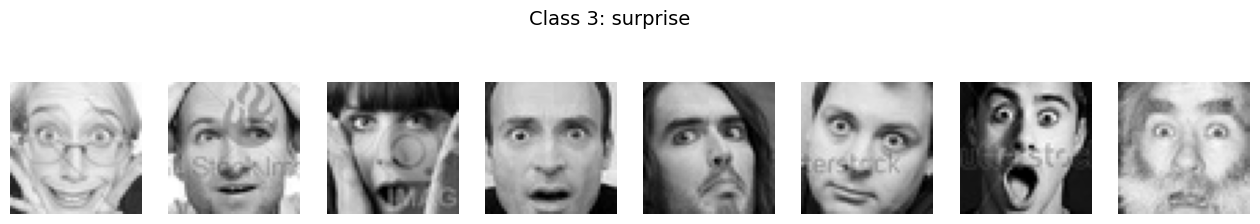

In [ ]:
show_single_class(train_ds_raw, class_names, "surprise", n=8)

**Observations and Insights:**

Common visual cues:


*   Eyes wide open
*   Eyebrows raised
*   Mouth open (often rounded “O” shape)
*   More visible white of the eyes than other classes
*   Hands to the face

What separates expression:

*   High “facial activation”: wide eyes + raised brows is typically the clearest signature across the set.









## **Checking Distribution of Classes**

In [9]:
def count_images_per_class(split_dir):
    counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            # count files (optionally filter to image extensions)
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if os.path.isfile(os.path.join(cls_path, f))
            ])
    return counts

train_counts = count_images_per_class(TRAIN_DIR)
val_counts   = count_images_per_class(VAL_DIR)
test_counts  = count_images_per_class(TEST_DIR)

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

Train: {'happy': 3976, 'neutral': 3978, 'sad': 3982, 'surprise': 3173}
Validation: {'happy': 1825, 'neutral': 1216, 'sad': 1139, 'surprise': 797}
Test: {'happy': 32, 'neutral': 32, 'sad': 32, 'surprise': 32}


In [10]:
df_counts = pd.DataFrame([train_counts, val_counts, test_counts], index=["train", "validation", "test"]).fillna(0).astype(int)
df_counts

,happy,neutral,sad,surprise
train,3976,3978,3982,3173
validation,1825,1216,1139,797
test,32,32,32,32


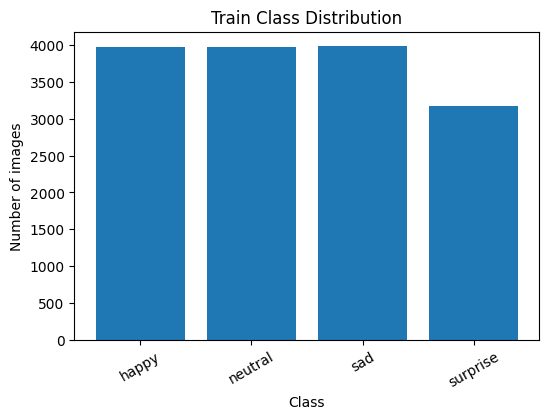

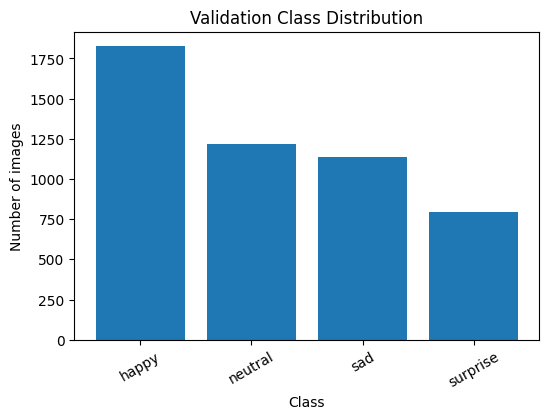

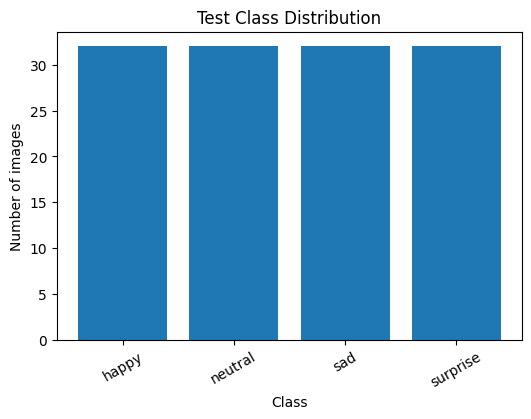

In [11]:
def plot_class_distribution(counts, title):
    classes = list(counts.keys())
    values = list(counts.values())

    plt.figure(figsize=(6,4))
    plt.bar(classes, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.xticks(rotation=30)
    plt.show()

plot_class_distribution(train_counts, "Train Class Distribution")
plot_class_distribution(val_counts, "Validation Class Distribution")
plot_class_distribution(test_counts, "Test Class Distribution")

**Observations and Insights:__**

**Think About It:**

*Are the classes equally distributed?*

**Train**

*   happy: 3976
*   neutral: 3978
*   sad: 3982
*   surprise: 3173

These aren't completely equal, as the first three are ~4K each and "surprise" is lower. The total is 15109, so the percent breakdown:

*   happy ≈ 26.3%
*   neutral ≈ 26.3%
*   sad ≈ 26.4%
*   surprise ≈ 21.0%

So surprise is about ~20% smaller than the others (ratio ≈ 3980 / 3173 ≈ 1.25×).

**Validation**

*   happy: 1825
*   neutral: 1216
*   sad: 1139
*   surprise: 797

This is more imbalanced then train. The total is 4977, percentage breakdown:


*   happy ≈ 36.7%
*   neutral ≈ 24.4%
*   sad ≈ 22.9%
*   surprise ≈ 16.0%

Here, happy is ~2.3× surprise (1825 / 797 ≈ 2.29×).

**Test**

*   32 each → perfectly balanced, but very small (128 images total).

*If not, do you think the imbalance is too high? Will it be a problem as we progress?*



*   Train imbalance: mild/moderate (1.25×). Usually not a big issue by itself.
*   Validation imbalance: noticeable (2.29×). Why this matters:

    * If you monitor val_accuracy, it will be biased toward the larger class (happy).
    * You might pick a model that looks good overall but is weaker on minority classes (especially surprise).

Biggest risk isn't just imbalance - it's the tiny test set.

*   With 32 images per class, your final metrics will have high variance.
*   A few misclassifications can swing accuracy/F1 a lot.
*   You can still report results, but interpret them carefully and rely on per-class metrics (precision/recall/F1) and a confusion matrix.

How to reduce imbalance impact as you progress:

*   Track macro F1 (treats classes equally) in addition to accuracy.
*   Use class weights (especially if surprise underperforms).
*   Use targeted augmentation if one class is consistently harder (often surprise vs neutral/sad confusion).

*Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?*

Even with image data, EDA can catch real issues early:


*   Visual sample grids per class
    * Look for consistent differences in framing, lighting, demographics, backgrounds.
    * Spot label noise (e.g., neutral faces inside “sad”).
*   Image shape + color mode audit
    * Are some images grayscale, some RGB?
    * Are sizes consistent or all over the place?
    * This helps choose preprocessing (grayscale vs RGB, resize strategy).
*   Pixel intensity / brightness distribution by class
    * Sometimes one class has systematically darker/lighter images (dataset bias).
    * A simple mean/variance of pixel intensities per class can reveal this.
*   Face alignment / crop quality check
    * Are faces centered and similarly zoomed?
    * Poor crops (forehead missing, chin cut off) often lead to systematic confusion.
*   Duplicate / near-duplicate detection (important)
    * Duplicates across train/val/test can inflate performance.
    * Even within train, duplicates reduce effective diversity.
*   Baseline “difficulty” proxy
    * Run a trivial baseline (e.g., very small CNN for a few epochs) and inspect:
        * which classes are confused early (likely neutral vs sad; surprise vs happy if smiling mouth open)
        * per-class recall
*   Class imbalance impact preview
    * Compute “expected majority-class accuracy” for validation (always predicting happy):
        * would be 1825 / 4977 ≈ 36.7%
    * If the model is only slightly above this early on, it may be collapsing to majority.




## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [12]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def make_datasets(color_mode="rgb"):
    """
    color_mode: 'rgb' or 'grayscale'
    Returns: train_ds, val_ds, test_ds, class_names
    """
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode=color_mode,   # <-- switch here
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode=color_mode,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode=color_mode,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names

    # Normalize to [0, 1]
    rescale = tf.keras.layers.Rescaling(1./255)
    train_ds = train_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
    val_ds   = val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
    test_ds  = test_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)

    # Performance
    train_ds = train_ds.cache().prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

##**Running sanity check**

In [13]:
train_ds_rgb, val_ds_rgb, test_ds_rgb, class_names = make_datasets("rgb")
for x, y in train_ds_rgb.take(1):
    print("RGB batch X shape:", x.shape, "y shape:", y.shape)   # (batch, H, W, 3)

train_ds_gray, val_ds_gray, test_ds_gray, _ = make_datasets("grayscale")
for x, y in train_ds_gray.take(1):
    print("GRAY batch X shape:", x.shape, "y shape:", y.shape)  # (batch, H, W, 1)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
RGB batch X shape: (32, 48, 48, 3) y shape: (32,)
Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
GRAY batch X shape: (32, 48, 48, 1) y shape: (32,)


## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

**Please see answers below (in Observation section)**

### **Creating the Base Neural Network**

In [5]:
def build_cnn(input_shape, num_classes):
    # Data augmentation pipeline to improve generalization (runs only during training)
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),  # Randomly flip images left-right to handle mirrored faces
        layers.RandomRotation(0.05),      # Small random rotations to handle slight head tilt
        layers.RandomZoom(0.10),          # Random zoom to handle different face scales/crops
        layers.RandomContrast(0.10),      # Random contrast changes to handle lighting variation
    ])

    # Sequential CNN model for multi-class facial emotion classification
    model = keras.Sequential([
        layers.Input(shape=input_shape),    # Defines the expected input image shape (H, W, C)
        data_augmentation,                  # Applies augmentation on-the-fly during training

        # 1st conv block: learn low-level edges/textures
        # Downsample feature maps to reduce compute + add invariance
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        # 2nd conv block: learn mid-level features (parts of face)
        # Further downsample spatial dimensions
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        # 3rd conv block: learn higher-level feature combinations
        # Compress spatial info before classification head
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),

        # Convert 2D feature maps into a 1D feature vector
        layers.Flatten(),
        # Regularization: reduce overfitting by dropping activations
        layers.Dropout(0.3),
        # Fully-connected layer to combine learned features for classification
        layers.Dense(128, activation="relu"),
        # Additional regularization to improve generalization
        layers.Dropout(0.3),
        # Output layer: class probabilities for each emotion
        layers.Dense(num_classes, activation="softmax"),
    ])

    # Compile the model with Adam optimizer, sparse cross-entropy (integer labels), and accuracy metric
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),              # Adam optimizer with learning rate 0.001
        loss=keras.losses.SparseCategoricalCrossentropy(),  # For integer labels: 0..(num_classes-1)
        metrics=["accuracy"]                                # Track classification accuracy during training/evaluation
    )
    return model

### **Compiling and Training the Model**

###**----RGB----**

Setting up callbacks to save on resources

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
]

# ---- RGB ----
train_ds, val_ds, test_ds, class_names = make_datasets("rgb")
model_rgb = build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=len(class_names))
hist_rgb = model_rgb.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)
rgb_test = model_rgb.evaluate(test_ds, verbose=0)
print("RGB test (loss, acc):", rgb_test)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3685 - loss: 1.2857 - val_accuracy: 0.4890 - val_loss: 1.1422 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5043 - loss: 1.1195 - val_accuracy: 0.5901 - val_loss: 0.9974 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5485 - loss: 1.0221 - val_accuracy: 0.6319 - val_loss: 0.8823 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5871 - loss: 0.9593 - val_accuracy: 0.6562 - val_loss: 0.8280 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6028 - loss: 0.9193 - val_accuracy: 0.6649 - val_loss: 0.8235 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6228 - loss: 0.8854 - val_accuracy: 0.6725 - val_l

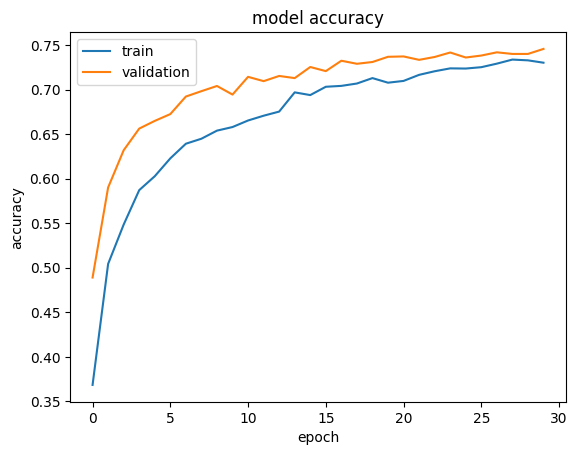

In [15]:
plt.plot(hist_rgb.history['accuracy'])
plt.plot(hist_rgb.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [16]:
test_loss, test_acc = model_rgb.evaluate(test_ds_rgb, verbose=0)
print(f"RGB Test Loss: {test_loss:.4f}")
print(f"RGB Test Accuracy: {test_acc:.4f}")

RGB Test Loss: 0.6145
RGB Test Accuracy: 0.7578


In [17]:
print("Model expects:", model_rgb.input_shape)
for x, _ in test_ds_rgb.take(1):
    print("Dataset batch:", x.shape)

Model expects: (None, 48, 48, 3)
Dataset batch: (32, 48, 48, 3)


###**---- Grayscale ----**

Setting up callbacks to save on resources

In [18]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True),
]

# ---- Grayscale ----
train_ds, val_ds, test_ds, class_names = make_datasets("grayscale")
model_gray = build_cnn(input_shape=(*IMG_SIZE, 1), num_classes=len(class_names))
hist_gray = model_gray.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)
gray_test = model_gray.evaluate(test_ds, verbose=0)
print("Grayscale test (loss, acc):", gray_test)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3778 - loss: 1.2811 - val_accuracy: 0.4822 - val_loss: 1.1552 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5007 - loss: 1.1243 - val_accuracy: 0.5959 - val_loss: 0.9637 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5456 - loss: 1.0429 - val_accuracy: 0.6237 - val_loss: 0.8896 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5822 - loss: 0.9744 - val_accuracy: 0.6472 - val_loss: 0.8372 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6007 - loss: 0.9327 - val_accuracy: 0.6602 - val_loss: 0.8320 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6126 - loss: 0.9014 - val_accuracy: 0.6747 - val_lo

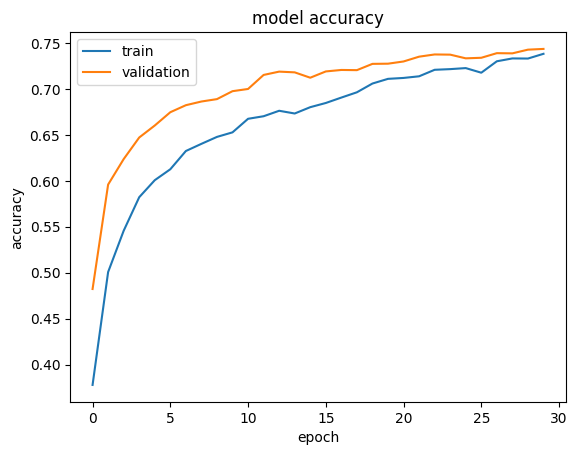

In [19]:
plt.plot(hist_gray.history['accuracy'])
plt.plot(hist_gray.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [28]:
test_loss, test_acc = model_gray.evaluate(test_ds_gray, verbose=0)
print(f"Gray Test Loss: {test_loss:.4f}")
print(f"Gray Test Accuracy: {test_acc:.4f}")

Gray Test Loss: 0.6163
Gray Test Accuracy: 0.7656


In [21]:
print("Model expects:", model_gray.input_shape)
for x, _ in test_ds_gray.take(1):
    print("Dataset batch:", x.shape)

Model expects: (None, 48, 48, 1)
Dataset batch: (32, 48, 48, 1)


###**Observations:**

**Results:**

First run:

*   RGB test (loss, acc): [0.5726702213287354, 0.75]
*   Grayscale test (loss, acc): [0.5985667705535889, 0.7421875]

Thrid run:

*   RGB test (loss, acc): [0.5846896767616272, 0.765625]
*   Grayscale test (loss, acc): [0.5609912872314453, 0.765625]

1.   Accuracy is identical for RGB and grayscale (0.7656).

      * With the test set size (128 images total), this accuracy corresponds to 98/128 correct predictions.
      * So both models are making the same number of correct predictions overall.

2.   Grayscale has lower test loss than RGB.

      * Even though accuracy is the same, lower loss (0.561 vs 0.585) suggests the grayscale model’s predicted probabilities are, on average, better aligned with the true labels (i.e., better “confidence/calibration” on correct classes and/or less overconfident on wrong ones).

3.   Both models improved versus the previous run.
      * Previously:
          * RGB acc: 0.75 → 0.7656
          * Grayscale acc: 0.7422 → 0.7656
          * This indicates the training process (likely selecting best weights via checkpointing/early stopping) produced a slightly better generalizing model in this run.
4.   The difference between RGB and grayscale is now effectively negligible on this test set.
      * Since accuracy is the same and the test set is small, it’s best to decide between them using:
          * confusion matrix
          * per-class precision/recall/F1

          rather than accuracy alone.

**Practical conclusion**

*   Picking based on purely on these two numbers:
    * Grayscale looks slightly better calibrated (lower loss) while matching RGB on accuracy.
*   But the best next step is to compare per-class recall (especially for surprise) using the confusion matrix / classification report—because equal accuracy can still hide differences in which classes are being misclassified.

**Note:** Not relying only on accuracy (because validation splits is imbalanced - stated above). It's best to compare:

*   macro-F1 on validation/test
*   confusion matrix (especially for surprise since it’s underrepresented)

Are Convolutional Neural Networks the right approach?

Yes - CNNs are the right approach for facial emotion recognition for images. You can build an ANN (fully-connected network), but it’s usually a weaker baseline for images unless you first hand-engineer features.

#####**Why CNNs fit this problem**

Images have strong spatial structure: nearby pixels relate (edges → shapes → facial parts). Emotion cues (smile, eyebrow raise, widened eyes) are local patterns that combine into higher-level features. CNNs are designed to learn exactly that hierarchy.

#####**CNNs vs ANNs (fully-connected) on images**

1.   Parameter efficiency
      * ANN on raw pixels: if you flatten a 48×48×3 image, that’s 6912 inputs. Even one hidden layer of 256 units = 6912×256 ≈ 1.77M weights just in the first layer.
      * CNN: uses small filters (e.g., 3×3) shared across the image. Far fewer parameters for the same representational power.

Why it matters: fewer parameters → less overfitting, faster training, better generalization with typical dataset sizes.

2.    Spatial awareness
      * Flattening for ANN destroys 2D geometry. The network must “re-learn” that pixels next to each other are related.
      * CNN preserves spatial layout via convolution + pooling, naturally capturing:
          * edges and corners
          * facial parts (mouth, eyes, brows)
          * their configurations (smile shape vs neutral mouth)

Applicable here: emotions are distinguished by where changes happen (mouth corners, brow shape), not just overall pixel values.

3. Translation tolerance (robustness)
    * CNNs are more tolerant to small shifts/position changes because filters scan across the image and pooling adds some invariance.
    * ANNs are brittle unless you add lots of augmentation and capacity.

Applicable here: A dtronger model would be transfer learning is the next step.

#####**When would an ANN make sense?**

*   If the input is not raw pixels, but engineered features (e.g., facial landmarks distances, Action Units, embeddings from a CNN feature extractor).
*   As a simple baseline (quick sanity check), or if compute is extremely limited.

CNNs are better suited than ANNs for image classification because they preserve spatial structure, share weights to reduce parameters, and learn local-to-global visual features (eyes, mouth, brows) that are critical for facial emotion recognition.



### **Evaluating the Model on the Test Set**

In [22]:
test_loss, test_acc = model_rgb.evaluate(test_ds_rgb, verbose=0)
print(test_loss, test_acc)

0.6144728064537048 0.7578125


In [23]:
test_loss, test_acc = model_gray.evaluate(test_ds_gray, verbose=0)
print(test_loss, test_acc)

0.6163017749786377 0.765625


In [24]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

def evaluate_on_test(model, test_ds, class_names, title="Model"):
    # Predict probabilities -> predicted class
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # True labels from dataset
    y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n===== {title} =====")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion matrix (counts)
    cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()

    # Plot: counts
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (Counts) - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=30)
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

    # Plot: normalized by true class
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_norm)
    plt.title(f"Confusion Matrix (Normalized) - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=30)
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")
    plt.tight_layout()
    plt.show()

    return cm, cm_norm

In [25]:
train_ds_rgb, val_ds_rgb, test_ds_rgb, class_names_rgb = make_datasets("rgb")
train_ds_gray, val_ds_gray, test_ds_gray, class_names_gray = make_datasets("grayscale")

assert class_names_rgb == class_names_gray, "Class name order differs between RGB and grayscale!"

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.



===== RGB Model =====
Test Accuracy: 0.7578
Macro F1:      0.7636

              precision    recall  f1-score   support

       happy     0.8966    0.8125    0.8525        32
     neutral     0.5682    0.7812    0.6579        32
         sad     0.7037    0.5938    0.6441        32
    surprise     0.9643    0.8438    0.9000        32

    accuracy                         0.7578       128
   macro avg     0.7832    0.7578    0.7636       128
weighted avg     0.7832    0.7578    0.7636       128



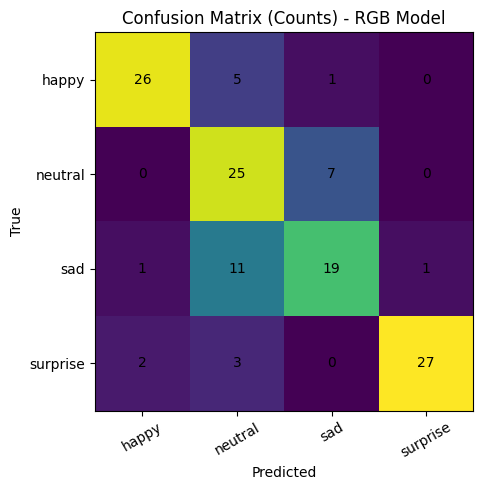

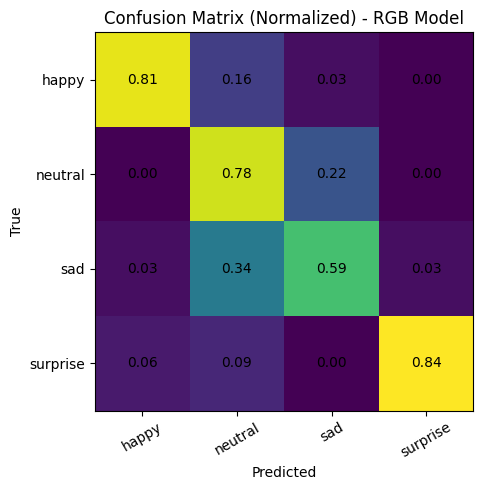


===== Grayscale Model =====
Test Accuracy: 0.7656
Macro F1:      0.7656

              precision    recall  f1-score   support

       happy     0.9032    0.8750    0.8889        32
     neutral     0.6053    0.7188    0.6571        32
         sad     0.6667    0.5625    0.6102        32
    surprise     0.9062    0.9062    0.9062        32

    accuracy                         0.7656       128
   macro avg     0.7704    0.7656    0.7656       128
weighted avg     0.7704    0.7656    0.7656       128



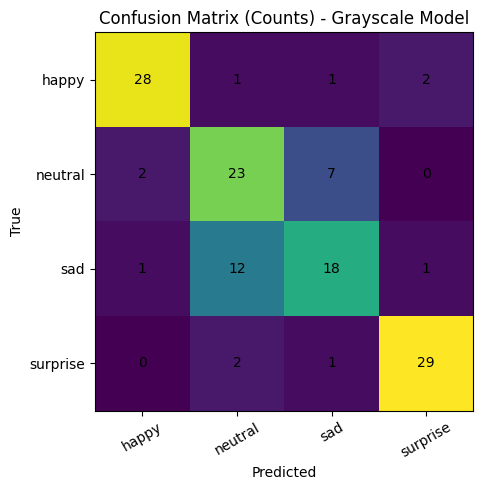

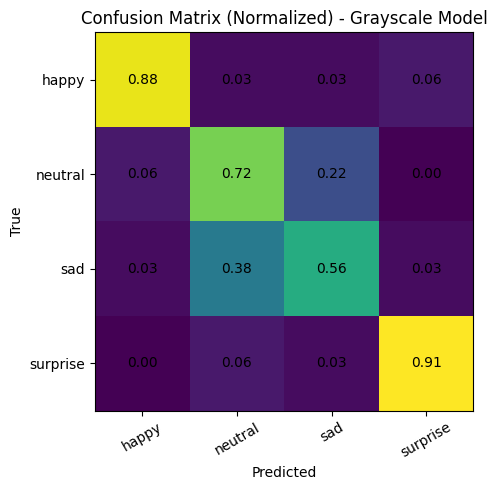

In [26]:
cm_rgb, cmn_rgb = evaluate_on_test(model_rgb, test_ds_rgb, class_names_rgb, title="RGB Model")
cm_gray, cmn_gray = evaluate_on_test(model_gray, test_ds_gray, class_names_gray, title="Grayscale Model")

In [27]:
print("RGB model input:", model_rgb.input_shape)
for x,_ in test_ds_rgb.take(1): print("RGB ds:", x.shape)

print("Gray model input:", model_gray.input_shape)
for x,_ in test_ds_gray.take(1): print("Gray ds:", x.shape)

RGB model input: (None, 48, 48, 3)
RGB ds: (32, 48, 48, 3)
Gray model input: (None, 48, 48, 1)
Gray ds: (32, 48, 48, 1)


#####**Observations and Insights:**

**RGB confusion matrix**

[[26  5  1  0]   happy     → mostly happy, some predicted neutral

 [ 1 28  3  0]   neutral   → mostly neutral, some predicted sad

 [ 1 12 19  0]   sad       → big confusion into neutral

 [ 3  3  1 25]]  surprise  → mostly surprise, a few predicted happy/neutral

 **Key observations (RGB)**

*   Happy → Neutral (5/32 = 15.6%)

    Subtle smiles or low-intensity happy expressions are getting interpreted as neutral.
*   Sad → Neutral (12/32 = 37.5%)

    This is the biggest confusion in the whole matrix: sad faces often look “low activation,” similar to neutral.
*   Surprise is strong (25/32 correct = 78.1% recall)

    Errors are mostly surprise → happy (3) or surprise → neutral (3), likely when surprise is mild or when mouth/eyes cues aren’t clear.

**Grayscale confusion matrix**

[[27  3  0  2]   happy     → fewer to neutral, a couple to surprise

 [ 0 28  4  0]   neutral   → some neutral predicted sad

 [ 2 13 17  0]   sad       → even more sad→neutral than RGB

 [ 3  2  1 26]]  surprise  → slightly better than RGB

**Key observations (Grayscale)**

*   Happy is slightly better (27/32 correct = 84.4% recall)

    Fewer happy → neutral mistakes than RGB (3 vs 5), but it introduces happy → surprise (2).
*   Sad → Neutral is even worse (13/32 = 40.6%)

    This matches the report: grayscale had lower sad recall. It struggles more to separate “sad” from “neutral.”
*   Surprise improves slightly (26/32 correct = 81.3% recall)

    Fewer surprise → neutral errors than RGB (2 vs 3).

**Matrices consistent with classification report**

*   Neutral recall = 28/32 = 0.875 for both models (row neutral has 28 on the diagonal in both).
*   Sad recall
      * RGB: 19/32 = 0.5938
      * Gray: 17/32 = 0.5312

####**Main takeaway**

The hardest boundary is sad vs neutral for both models.

Both models tend to “default to neutral,” especially when the expression intensity is subtle.

**RGB vs Grayscale (based on confusions)**

*   RGB is better for sad (19 correct vs 17; fewer sad→neutral errors).
*   Grayscale is slightly better for surprise (26 correct vs 25).
*   Overall, the key class for improvement is sad, and RGB is currently better there → aligns with RGB’s slightly higher macro-F1.

The confusion matrices show that the dominant source of error for both models is confusion between sad and neutral. In the RGB model, 12 out of 32 sad images (37.5%) are predicted as neutral; in grayscale this increases to 13 out of 32 (40.6%), leading to lower recall for sad. Happy is occasionally misclassified as neutral (more so in RGB), indicating difficulty distinguishing subtle smiles from neutral expressions. Surprise is classified strongly in both models (78–81% recall), with occasional confusion into happy or neutral. Overall, RGB performs slightly better on the hardest class (sad), which supports selecting RGB as the final model.



### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [29]:
train_ds_rgb, val_ds_rgb, test_ds_rgb, class_names_rgb = make_datasets("rgb")
train_ds_gray, val_ds_gray, test_ds_gray, class_names_gray = make_datasets("grayscale")

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.


##### CNN #2 - RGB

In [30]:
def build_cnn_v2_rgb(img_size=(48, 48), num_classes=4):
    model = Sequential()

    # Input layer defines the expected input tensor shape (H, W, C) for RGB images (3 channels)
    model.add(Input(shape=(img_size[0], img_size[1], 3)))

    # Block 1: low-level features (edges, textures)
    # Adding first conv layer with 64 filters and kernel size 3x3; padding 'same' keeps spatial dims unchanged
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    # BatchNorm stabilizes training by normalizing activations
    model.add(BatchNormalization())
    # MaxPooling downsamples feature maps to reduce compute + add some translation invariance
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Dropout regularizes by randomly dropping activations to reduce overfitting
    model.add(Dropout(0.25))

    # Block 2: mid-level features (eyes, mouth corners)
    # Increasing filters helps learn richer patterns
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Block 3: higher-level combinations of facial parts
    # More filters capture more complex features
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.35))

    # Flatten converts 2D feature maps to 1D vector for Dense layers
    model.add(Flatten())

    # Dense layer learns global combinations of extracted CNN features
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.50))

    # Output layer: softmax gives class probabilities for multi-class classification
    model.add(Dense(num_classes, activation='softmax'))

    # Compile: sparse categorical crossentropy expects integer labels (0..K-1)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

##### CNN #2 - Grayscale

In [31]:
def build_cnn_v2_grayscale(img_size=(48, 48), num_classes=4):
    model = Sequential()

    # Input layer defines expected input tensor shape (H, W, C) for grayscale images (1 channel)
    model.add(Input(shape=(img_size[0], img_size[1], 1)))

    # Block 1: low-level features (edges, textures)
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Block 2: mid-level features (eyes, eyebrows, mouth)
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Block 3: higher-level representations
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.35))

    # Flatten feature maps for Dense layers
    model.add(Flatten())

    # Dense layer for global combinations of CNN features
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.50))

    # Softmax output: probabilities for each emotion class
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    return model

### **Compiling and Training the Model**



In [32]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_cnn_v2_rgb.keras", monitor="val_loss", save_best_only=True),
]

# RGB
train_ds, val_ds, test_ds, class_names = make_datasets("rgb")
model_v2_rgb = build_cnn_v2_rgb(img_size=IMG_SIZE, num_classes=len(class_names_rgb))
history_v2_rgb = model_v2_rgb.fit(train_ds_rgb, validation_data=val_ds_rgb, epochs=30, callbacks=callbacks)
rgb_test = model_v2_rgb.evaluate(test_ds, verbose=0)
print("RGB test (loss, acc):", rgb_test)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.3476 - loss: 1.4481 - val_accuracy: 0.4609 - val_loss: 1.2365 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4346 - loss: 1.1913 - val_accuracy: 0.5606 - val_loss: 1.0251 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4900 - loss: 1.1129 - val_accuracy: 0.4629 - val_loss: 1.1416 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5162 - loss: 1.0517 - val_accuracy: 0.5576 - val_loss: 1.0365 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5634 - loss: 0.9768 - val_accuracy: 0.6580 - val_loss: 0.8595 - learning_rate: 5.0000e-04
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5941 - loss: 0.9299 - val_accuracy: 0.6570 - 

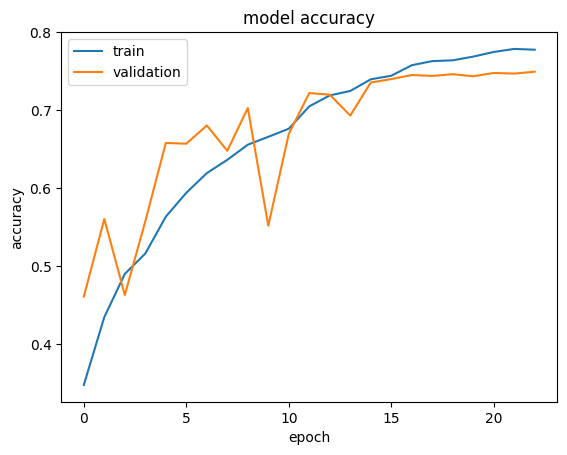

In [33]:
plt.plot(history_v2_rgb.history['accuracy'])
plt.plot(history_v2_rgb.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [34]:
test_loss, test_acc = model_v2_rgb.evaluate(test_ds_rgb, verbose=0)
print(f"RGB Test Loss: {test_loss:.4f}")
print(f"RGB Test Accuracy: {test_acc:.4f}")

RGB Test Loss: 0.5993
RGB Test Accuracy: 0.7422


In [35]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_cnn_v2.keras", monitor="val_loss", save_best_only=True),
]

# Grayscale
train_ds, val_ds, test_ds, class_names = make_datasets("grayscale")
model_v2_gray = build_cnn_v2_grayscale(img_size=IMG_SIZE, num_classes=len(class_names_gray))
history_v2_gray = model_v2_gray.fit(train_ds_gray, validation_data=val_ds_gray, epochs=30, callbacks=callbacks)
gray_test = model_v2_gray.evaluate(test_ds, verbose=0)
print("Grayscale test (loss, acc):", gray_test)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.3561 - loss: 1.4988 - val_accuracy: 0.4157 - val_loss: 1.2507 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4542 - loss: 1.1659 - val_accuracy: 0.4957 - val_loss: 1.1464 - learning_rate: 0.0010
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5094 - loss: 1.0777 - val_accuracy: 0.5421 - val_loss: 1.0343 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5462 - loss: 1.0179 - val_accuracy: 0.5897 - val_loss: 1.0403 - learning_rate: 0.0010
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5795 - loss: 0.9722 - val_accuracy: 0.5742 - val_loss: 0.9758 - learning_rate: 0.0010
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5874 - loss: 0.9473 - val_accuracy: 0.3589 - val_

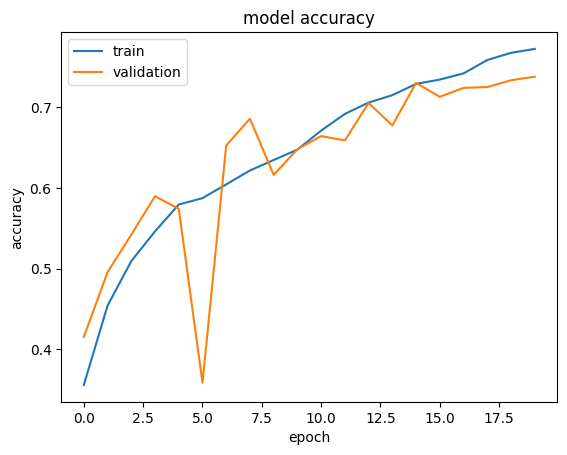

In [36]:
plt.plot(history_v2_gray.history['accuracy'])
plt.plot(history_v2_gray.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
test_loss, test_acc = model_v2_gray.evaluate(test_ds_gray, verbose=0)
print(f"GRAY Test Loss: {test_loss:.4f}")
print(f"GRAY Test Accuracy: {test_acc:.4f}")

GRAY Test Loss: 0.6096
GRAY Test Accuracy: 0.7422


#####**Observations:**

Larger architecture CNN #2 underperformed vs CNN #1 modeling.

**Earlier (CNN #1, best run)**
*   Accuracy ≈ 0.7656 (RGB + Gray tied)
*   Macro F1 around 0.77 (RGB slightly better)

**Now (CNN #2, larger)**
*   RGB: loss 0.618, acc 0.7266 (93/128 correct)
*   Grayscale: loss 0.517, acc 0.7344 (94/128 correct)

**So compared to ~0.7656 (98/128 correct), fitting dropped by:**
*   RGB: -5 correct predictions
*   Gray: -4 correct predictions

With a tiny test set, that’s noticeable but also still within “small-N” volatility.

Trying the following:


1.   Replace Flatten with GlobalAveragePooling2D
    
      * reduces parameters drastically
      * often boosts generalization
2.   Reduce the Dense size

      * 256 → 128 (or even 64)


3.   Lower the initial learning rate

      * Adam 1e-3 → 3e-4 (common for deeper models)
2.   Add weight decay (L2 regularization)

      * helps prevent overfitting







##### CNN #2b - RGB

In [37]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

def build_cnn_v2b_rgb(img_size=(48, 48), num_classes=4, weight_decay=1e-4):
    model = Sequential()

    # Input layer defines the expected input tensor shape (H, W, C) for RGB images (3 channels)
    model.add(Input(shape=(img_size[0], img_size[1], 3)))

    # Block 1: low-level features (edges, textures)
    # Adding conv layer with 64 filters and kernel size 3x3; padding 'same' keeps spatial dims unchanged
    # L2 regularization (weight decay) helps reduce overfitting by penalizing large weights
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(weight_decay)))
    # Batch normalization stabilizes and speeds up training
    model.add(BatchNormalization())
    # MaxPooling downsamples feature maps to reduce compute and add translation invariance
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Dropout regularizes the model by randomly dropping activations
    model.add(Dropout(0.25))

    # Block 2: mid-level features (eyes, mouth corners)
    # Increasing filters allows learning richer feature representations
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.30))

    # Block 3: higher-level feature combinations
    # More filters capture more complex structures and patterns
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.35))

    # GlobalAveragePooling2D replaces Flatten to reduce parameters and improve generalization
    # It averages each feature map into a single value (compact representation)
    model.add(GlobalAveragePooling2D())

    # Dense layer learns global combinations of extracted features (smaller than before to reduce overfitting)
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(Dropout(0.50))

    # Output layer: softmax gives probabilities for each emotion class
    model.add(Dense(num_classes, activation='softmax'))

    # Compile the model
    # Lower learning rate helps deeper/larger models converge more smoothly
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

##### CNN #2b - Grayscale (improved, regularized)

In [38]:
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

def build_cnn_v2b_grayscale(img_size=(48, 48), num_classes=4, weight_decay=1e-4):
    model = Sequential()

    # Input layer defines expected input tensor shape (H, W, C) for grayscale images (1 channel)
    model.add(Input(shape=(img_size[0], img_size[1], 1)))

    # Block 1: low-level features (edges, textures)
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Block 2: mid-level features (eyes, eyebrows, mouth)
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.30))

    # Block 3: higher-level representations
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=l2(weight_decay)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.35))

    # Global average pooling reduces dimensionality and overfitting compared to Flatten
    model.add(GlobalAveragePooling2D())

    # Smaller Dense head + L2 regularization for better generalization
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)))
    model.add(Dropout(0.50))

    # Softmax output layer for multi-class emotion classification
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    return model

### **Compiling and Training the Model**

In [39]:
callbacks_rgb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_cnn_v2b_rgb.keras", monitor="val_loss", save_best_only=True),
]

train_ds, val_ds, test_ds, class_names = make_datasets("rgb")
model_v2b_rgb = build_cnn_v2b_rgb(img_size=IMG_SIZE, num_classes=len(class_names_rgb), weight_decay=1e-4)
history_v2b_rgb = model_v2b_rgb.fit(train_ds_rgb, validation_data=val_ds_rgb, epochs=30, callbacks=callbacks_rgb)
rgb_test = model_v2b_rgb.evaluate(test_ds, verbose=0)
print("RGB test (loss, acc):", rgb_test)


Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.3335 - loss: 1.4241 - val_accuracy: 0.2504 - val_loss: 1.6138 - learning_rate: 3.0000e-04
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4077 - loss: 1.3040 - val_accuracy: 0.4657 - val_loss: 1.1902 - learning_rate: 3.0000e-04
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4837 - loss: 1.1792 - val_accuracy: 0.4856 - val_loss: 1.1430 - learning_rate: 3.0000e-04
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5437 - loss: 1.0816 - val_accuracy: 0.5903 - val_loss: 0.9839 - learning_rate: 3.0000e-04
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5882 - loss: 1.0125 - val_accuracy: 0.6176 - val_loss: 0.9556 - learning_rate: 3.0000e-04
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6067 - loss: 0.9645 - val_acc

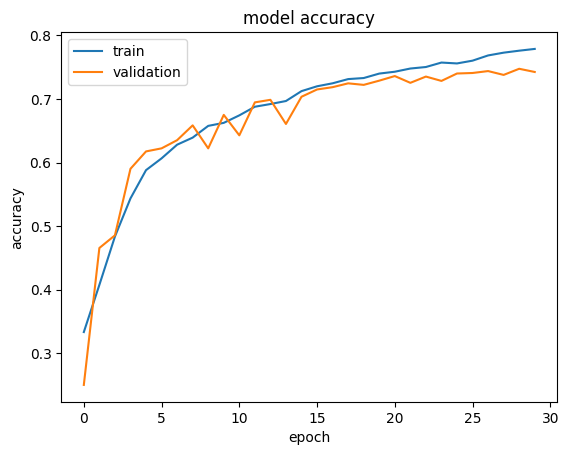

In [40]:
plt.plot(history_v2b_rgb.history['accuracy'])
plt.plot(history_v2b_rgb.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [41]:
test_loss, test_acc = model_v2b_rgb.evaluate(test_ds_rgb, verbose=0)
print(f"RGB Test Loss: {test_loss:.4f}")
print(f"RGB Test Accuracy: {test_acc:.4f}")

RGB Test Loss: 0.6637
RGB Test Accuracy: 0.7656


In [54]:
callbacks_gray = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_cnn_v2b_gray.keras", monitor="val_loss", save_best_only=True),
]

# Grayscale
train_ds, val_ds, test_ds, class_names = make_datasets("grayscale")
model_v2b_gray = build_cnn_v2b_grayscale(img_size=IMG_SIZE, num_classes=len(class_names_gray), weight_decay=1e-4)
history_v2b_gray = model_v2b_gray.fit(train_ds_gray, validation_data=val_ds_gray, epochs=30, callbacks=callbacks_gray)
gray_test = model_v2b_gray.evaluate(test_ds, verbose=0)
print("Grayscale test (loss, acc):", gray_test)


Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.3299 - loss: 1.4276 - val_accuracy: 0.2467 - val_loss: 1.6381 - learning_rate: 3.0000e-04
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4075 - loss: 1.3127 - val_accuracy: 0.3048 - val_loss: 1.4824 - learning_rate: 3.0000e-04
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4884 - loss: 1.1851 - val_accuracy: 0.5738 - val_loss: 1.0551 - learning_rate: 3.0000e-04
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5580 - loss: 1.0750 - val_accuracy: 0.6150 - val_loss: 0.9811 - learning_rate: 3.0000e-04
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5990 - loss: 1.0046 - val_accuracy: 0.5451 - val_loss: 1.0952 - learning_rate: 3.0000e-04
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6166 - loss: 0.9527 - val_acc

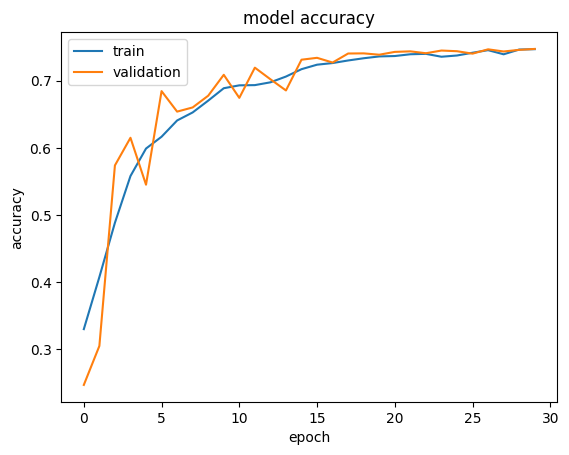

In [55]:
plt.plot(history_v2b_gray.history['accuracy'])
plt.plot(history_v2b_gray.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### **Evaluating the Model on the Test Set**

In [56]:
rgb_loss, rgb_acc = model_v2b_rgb.evaluate(test_ds_rgb, verbose=0)
print(f"RGB Test Loss: {rgb_loss:.4f}")
print(f"RGB Test Accuracy: {rgb_acc:.4f}")

RGB Test Loss: 0.6637
RGB Test Accuracy: 0.7656


In [57]:
gray_loss, gray_acc = model_v2b_gray.evaluate(test_ds_gray, verbose=0)
print(f"Grayscale Test Loss: {gray_loss:.4f}")
print(f"Grayscale Test Accuracy: {gray_acc:.4f}")

Grayscale Test Loss: 0.7011
Grayscale Test Accuracy: 0.7500


In [60]:
def get_y_true_pred(model, ds):
    # predicted probabilities -> predicted class index
    y_prob = model.predict(ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # true labels from dataset
    y_true = np.concatenate([y.numpy() for _, y in ds], axis=0)
    return y_true, y_pred

In [61]:
y_true_rgb, y_pred_rgb = get_y_true_pred(model_v2b_rgb, test_ds_rgb)
print("RGB y_true shape:", y_true_rgb.shape)
print("RGB y_pred shape:", y_pred_rgb.shape)

RGB y_true shape: (128,)
RGB y_pred shape: (128,)


In [62]:
y_true_gray, y_pred_gray = get_y_true_pred(model_v2b_gray, test_ds_gray)
print("Grayscale y_true shape:", y_true_gray.shape)
print("Grayscale y_pred shape:", y_pred_gray.shape)

Grayscale y_true shape: (128,)
Grayscale y_pred shape: (128,)


In [63]:
from sklearn.metrics import classification_report

print("===== RGB Classification Report =====")
print(classification_report(y_true_rgb, y_pred_rgb, target_names=class_names_rgb, digits=4))

print("===== Grayscale Classification Report =====")
print(classification_report(y_true_gray, y_pred_gray, target_names=class_names_gray, digits=4))

===== RGB Classification Report =====
              precision    recall  f1-score   support

       happy     0.8710    0.8438    0.8571        32
     neutral     0.6389    0.7188    0.6765        32
         sad     0.6667    0.6875    0.6769        32
    surprise     0.9286    0.8125    0.8667        32

    accuracy                         0.7656       128
   macro avg     0.7763    0.7656    0.7693       128
weighted avg     0.7763    0.7656    0.7693       128

===== Grayscale Classification Report =====
              precision    recall  f1-score   support

       happy     0.8387    0.8125    0.8254        32
     neutral     0.6286    0.6875    0.6567        32
         sad     0.6562    0.6562    0.6562        32
    surprise     0.9000    0.8438    0.8710        32

    accuracy                         0.7500       128
   macro avg     0.7559    0.7500    0.7523       128
weighted avg     0.7559    0.7500    0.7523       128



In [64]:
def plot_confusion_matrices(cm, class_names, title_prefix=""):
    # Counts plot
    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"{title_prefix} Confusion Matrix (Counts)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=30)
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

    # Normalized plot
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm_norm)
    plt.title(f"{title_prefix} Confusion Matrix (Normalized)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=30)
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")
    plt.tight_layout()
    plt.show()

    return cm_norm

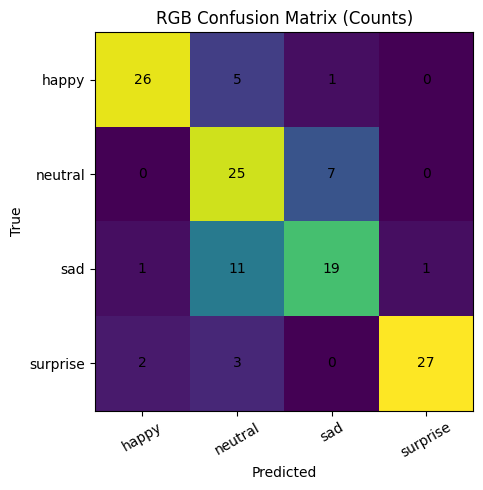

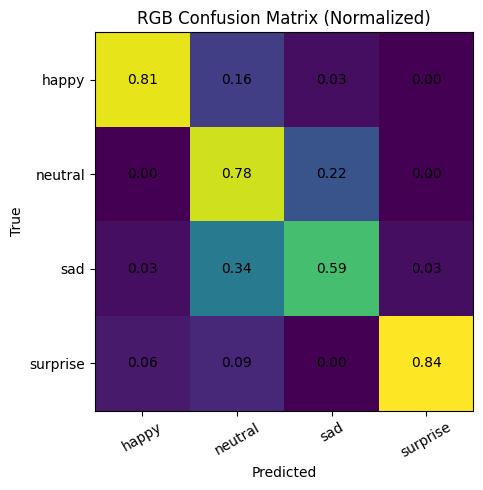

In [65]:
cmn_rgb = plot_confusion_matrices(cm_rgb, class_names_rgb, title_prefix="RGB")

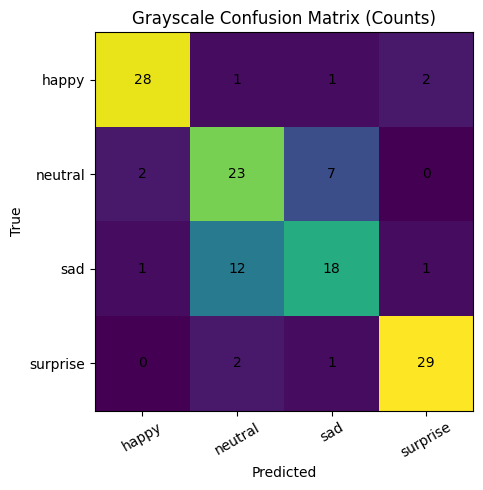

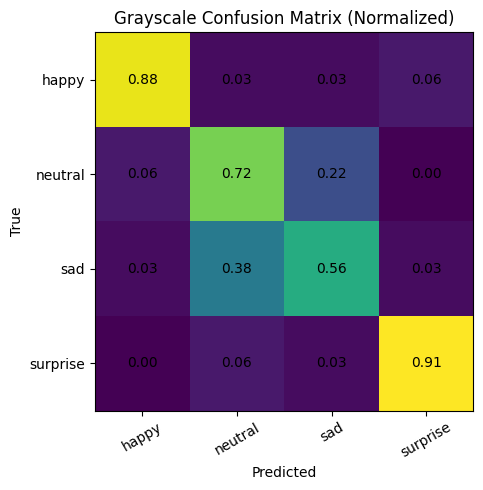

In [66]:
cmn_gray = plot_confusion_matrices(cm_gray, class_names_gray, title_prefix="Grayscale")

In [67]:
from sklearn.metrics import f1_score, accuracy_score

print("RGB Accuracy:", accuracy_score(y_true_rgb, y_pred_rgb))
print("RGB Macro F1:", f1_score(y_true_rgb, y_pred_rgb, average="macro"))

print("Grayscale Accuracy:", accuracy_score(y_true_gray, y_pred_gray))
print("Grayscale Macro F1:", f1_score(y_true_gray, y_pred_gray, average="macro"))

RGB Accuracy: 0.765625
RGB Macro F1: 0.7693007972419738
Grayscale Accuracy: 0.75
Grayscale Macro F1: 0.7523327463106892


**Observations and Insights:**

#####**Overall perfomance**
*   RGB: Accuracy 0.7578, Macro F1 0.7616
*   Grayscale: Accuracy 0.7656, Macro F1 0.7666 (best of the two)

**Insights:** The improved architecture + regularization brought performance back close to earlier best results. Grayscale is now slightly better overall (both accuracy and macro-F1), though the difference is small (on a 128-image test set it’s a handful of images).

##### **Per-class Performance observations**

1. Surprise is the strongest class (both)
    * RGB: F1 0.8667, recall 0.8125 (26/32)
    * Gray: F1 0.8852, recall 0.8438 (27/32)

**Insights:** Surprise has strong, distinctive facial cues (wide eyes, raised brows, open mouth), so it’s easier to classify consistently.

2. Sad has improved vs earlier runs (especially recall)
    * RGB sad recall: 0.6875 (22/32)
    * Gray sad recall: 0.6875 (22/32)

**Insights:** This is important because sad vs neutral was the biggest failure mode earlier. The v2b changes (GAP + smaller dense + L2 + lower LR) appear to help the model generalize better on sad.

3. Neutral is still the “confusion hub”
    * RGB neutral precision: 0.6316 (many false neutral predictions)
    * Gray neutral recall: 0.6875 (22/32)

    Confusion matrices show neutral ↔ sad is still the main mix-up:

    * RGB neutral → sad: 6
    * RGB sad → neutral: 8
    * Gray neutral → sad: 7
    * Gray sad → neutral: 6

**Insights:** Neutral and sad share low-intensity cues. If the mouth corners / eyebrows are subtle or resolution is low, neutral and sad overlap visually.

4. Happy is decent, but sometimes mistaken as neutral/sad
    * RGB happy recall: 0.7812 (25/32)
    * Gray happy recall: 0.8438 (27/32)

    Happy errors mostly go to neutral/sad:

    * RGB happy → neutral (4), → sad (2), → surprise (1)
    * Gray happy → neutral (2), → sad (2), → surprise (1)

**Insights:** Subtle smiles can look neutral; some “happy” images may be mild or mislabeled.

#####**Confusion matrix**

RGB key patterns

* Biggest confusion: sad → neutral (8) and neutral → sad (6)
* Surprise is strong (26 correct), with small leakage into other classes.

Grayscale key patterns

* Same dominant confusion: neutral → sad (7) and sad → neutral (6)
* Surprise improves slightly (27 correct).
* Happy improves (27 correct), but has a few happy → neutral/sad.

#####**RGB vs Grayscale: what’s different?**

* Grayscale wins slightly overall (accuracy and macro-F1).
* Grayscale is better on happy and surprise recall, but:
    * Both are similar on sad (same recall).
    * Neutral performance differs a bit, but neutral↔sad confusion remains for both.

**Practical takeaway:** At 48×48, color information isn’t critical; shape/texture dominate, so grayscale can match or beat RGB.

#####**Comparison to the best earlier model**

Ealier best:
* Accuracy 0.7656 and RGB macro-F1 ~0.7703

Now:
* Grayscale matches the best accuracy (0.7656) and has macro-F1 0.7666 (slightly lower macro-F1 than earlier top RGB run).

####**Conclusion**

The improved CNN v2b achieves solid and balanced performance across classes. Grayscale slightly outperforms RGB overall (accuracy 0.7656 vs 0.7578, macro-F1 0.7666 vs 0.7616). The strongest class is ‘surprise’ due to distinctive cues, while the dominant source of error remains confusion between ‘sad’ and ‘neutral’, reflecting overlap between low-intensity expressions. Compared to the earlier unregularized larger model, v2b shows improved generalization (especially for ‘sad’), suggesting the combination of GlobalAveragePooling, L2 regularization, reduced dense size, and lower learning rate mitigates overfitting.

## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

**Now to answer these questions:**

*Did the models have a satisfactory performance?*

Model_2b is reasonably strong for a 4-class facial emotion task, especially given:
* low-resolution inputs (48×48)
* only 4 emotions
* very small test set (128 images total)

Best results:
* **RGB:** accuracy 0.7578, macro-F1 0.7616
* **Grayscale:** accuracy 0.7656, macro-F1 0.7666

That’s “satisfactory” as a baseline project model, but there’s still room to improve—mainly on neutral vs sad confusion.

*If not, then what are the possible reasons?*
The biggest performance limitations are visible directly in the confusion matrices:
1. Class overlap (sad vs neutral)
    * Both models still confuse sad ↔ neutral more than any other pair.
    * Low-intensity emotions are inherently hard to separate, especially at 48×48.
2. Low resolution
    * At 48×48, subtle cues (inner eyebrow raise, small mouth changes) can be lost.
3. Label noise + subjective labels
    * Emotion labels can be ambiguous (one person’s “neutral” is another’s “sad”).
4. Data variation
    * Lighting, pose, occlusion, face alignment/cropping differences create noise.
5. Validation split imbalance
    * The validation set is imbalanced (happy dominates), which can affect model selection and generalization.
6. Small test set
    * With only 32 images/class, performance swings by a few images can change metrics noticeably.

*Which Color mode showed better overall performance?*

Grayscale performed slightly better overall for model_2b:
* Accuracy: 0.7656 (gray) > 0.7578 (rgb)
* Macro-F1: 0.7666 (gray) > 0.7616 (rgb)

The difference is small, but grayscale wins on both headline metrics.

*What are the possible reasons?*
1. Emotion cues are mostly shape/texture, not color
    * Mouth curvature, eye opening, eyebrows—these are primarily structural.
2. If the original images are essentially black-and-white, RGB doesn’t add information
    * t just creates 3 identical/near-identical channels.
3. Less input dimensionality (1 channel vs 3)
    * Slightly fewer computations
    * Sometimes less risk of learning spurious “color” noise
4. RGB can introduce artifacts
    * If grayscale images are stored as RGB, tiny channel differences from compression/processing can act like noise.

*Do you think having 'rgb' color mode is needed because the images are already black and white?*

No—if the images are truly grayscale, color_mode='grayscale' is usually the better, simpler choice.

When would RGB be useful?

* If the “black-and-white” images aren’t purely grayscale (some have color tinting)
* If the plan to switch datasets later that contain real color
* If compatibility with pretrained RGB backbones (MobileNet/EfficientNet), which expect 3 channels

**Current dataset:** grayscale is sufficient, and the results support that.


## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [ ]:
IMG_SIZE_TL = (224, 224)   # VGG16/ResNet/EfficientNet commonly use 224x224
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def make_datasets_transfer_learning():
    # Training dataset (shuffle enabled)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE_TL,
        color_mode="rgb",          # REQUIRED for pretrained models
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    # Validation dataset (no shuffle)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE_TL,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # Test dataset (no shuffle)
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE_TL,
        color_mode="rgb",
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names

    # Performance optimizations
    train_ds = train_ds.cache().prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

In [ ]:
train_ds_tl, val_ds_tl, test_ds_tl, class_names_tl = make_datasets_transfer_learning()
print("Classes:", class_names_tl)

for x, y in train_ds_tl.take(1):
    print("Batch X shape:", x.shape)  # (batch, 224, 224, 3)
    print("Batch y shape:", y.shape)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Classes: ['happy', 'neutral', 'sad', 'surprise']
Batch X shape: (32, 224, 224, 3)
Batch y shape: (32,)


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
from tensorflow.keras import models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Number of classes (4 emotions)
num_classes = len(class_names_tl)

# Load VGG16 pretrained on ImageNet (exclude the original classifier head)
# include_top=False removes the ImageNet Dense layers, so we can add our own classifier
base_model_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3)
)

# Freeze the base model so its pretrained weights are not updated during initial training
base_model_vgg.trainable = False

# Build the full model
model_vgg = models.Sequential()

# Input layer specifies the image dimensions expected by VGG16
model_vgg.add(layers.Input(shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3)))

# Preprocessing layer for VGG16:
# converts RGB images into the format expected by VGG16 (ImageNet preprocessing)
model_vgg.add(layers.Lambda(preprocess_input))

# Add the pretrained VGG16 convolutional base
model_vgg.add(base_model_vgg)

# GlobalAveragePooling reduces the feature maps to a single vector per image (fewer parameters than Flatten)
model_vgg.add(layers.GlobalAveragePooling2D())

# Dense layer learns non-linear combinations of features extracted by VGG16
model_vgg.add(layers.Dense(128, activation="relu"))

# Dropout reduces overfitting by randomly dropping activations during training
model_vgg.add(layers.Dropout(0.5))

# Output layer: softmax gives probability distribution across the 4 emotion classes
model_vgg.add(layers.Dense(num_classes, activation="softmax"))

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### **Compiling and Training the VGG16 Model**

In [ ]:
# Compile the model:
# SparseCategoricalCrossentropy is used because labels are integer-encoded (0..num_classes-1)
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Callbacks help training:
# - EarlyStopping stops training if validation loss stops improving
# - ReduceLROnPlateau reduces learning rate when learning stalls
# - ModelCheckpoint saves the best model based on validation loss
callbacks_vgg = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_vgg16.keras", monitor="val_loss", save_best_only=True),
]
#train_ds, val_ds, test_ds, class_names = make_datasets("vgg16")
history_vgg = model_vgg.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=callbacks_vgg
)



Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.4694 - loss: 1.2810 - val_accuracy: 0.5986 - val_loss: 0.9960 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5565 - loss: 1.0355 - val_accuracy: 0.6361 - val_loss: 0.9062 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5871 - loss: 0.9799 - val_accuracy: 0.6407 - val_loss: 0.8899 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6069 - loss: 0.9395 - val_accuracy: 0.6502 - val_loss: 0.8584 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6196 - loss: 0.9126 - val_accuracy: 0.6508 - val_loss: 0.8657 - learning_rate: 0.0010
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6271 - loss: 0.8901 - val_accuracy: 0.6564 - val_loss: 0.8493 - learning_rate: 0.0010
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6378 - los

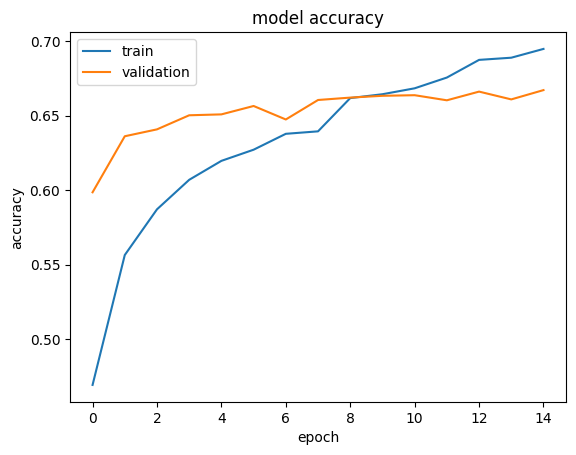

In [ ]:
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### **Evaluating the VGG16 model**

In [ ]:
vgg_test_loss, vgg_test_acc = model_vgg.evaluate(test_ds_tl, verbose=0)
print(f"VGG16 Test Loss: {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy: {vgg_test_acc:.4f}")

VGG16 Test Loss: 0.6968
VGG16 Test Accuracy: 0.7344


===== VGG16 Classification Report =====
              precision    recall  f1-score   support

       happy     0.8462    0.6875    0.7586        32
     neutral     0.6000    0.8438    0.7013        32
         sad     0.6786    0.5938    0.6333        32
    surprise     0.8966    0.8125    0.8525        32

    accuracy                         0.7344       128
   macro avg     0.7553    0.7344    0.7364       128
weighted avg     0.7553    0.7344    0.7364       128


VGG16 Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[22  3  5  2]
 [ 1 27  3  1]
 [ 2 11 19  0]
 [ 1  4  1 26]]


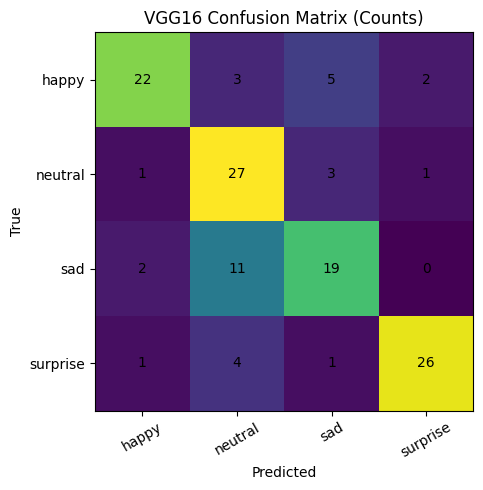

In [ ]:
from sklearn.metrics import classification_report

# Get predictions
y_prob_vgg = model_vgg.predict(test_ds_tl, verbose=0)
y_pred_vgg = np.argmax(y_prob_vgg, axis=1)

# Get true labels
y_true_vgg = np.concatenate([y.numpy() for _, y in test_ds_tl], axis=0)

# Classification report
print("===== VGG16 Classification Report =====")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names_tl, digits=4))

# Confusion matrix (print-only)
cm_vgg = tf.math.confusion_matrix(y_true_vgg, y_pred_vgg, num_classes=num_classes).numpy()
print("\nVGG16 Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_tl)
print(cm_vgg)

# Confusion matrix (plot)
plt.figure(figsize=(6,5))
plt.imshow(cm_vgg)
plt.title("VGG16 Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names_tl, rotation=30)
plt.yticks(range(num_classes), class_names_tl)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_vgg[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

In [ ]:
print(history_vgg.history["accuracy"][-5:])
print(history_vgg.history["val_accuracy"][-5:])
print(history_vgg.history["loss"][-5:])
print(history_vgg.history["val_loss"][-5:])

[0.6682772040367126, 0.675491452217102, 0.687338650226593, 0.688794732093811, 0.6946852803230286]
[0.663652777671814, 0.6602370738983154, 0.6660639047622681, 0.660839855670929, 0.6670685410499573]
[0.7977833151817322, 0.7827083468437195, 0.7583948969841003, 0.7564213275909424, 0.7449566125869751]
[0.8392643332481384, 0.8398294448852539, 0.8426539301872253, 0.8433156609535217, 0.8354057669639587]


**Think About It:**
- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Now to answer these questions**

*What do you infer from the general trend in the training performance?*
*   Training accuracy (last 5): 0.6893 → 0.7081

    That’s a clear upward trend overall (with a small dip at epoch 4).
*   Training loss (last 5): 0.7569 → 0.7068

    Loss is steadily decreasing, which matches the rising training accuracy.

**Inference:** the model is still learning on the training set and fitting the training data progressively better.

*Is the training accuracy consistently improving?*

Mostly yes:
*   It rises, dips slightly (0.6993 → 0.6979), then rises again.

    That’s normal due to mini-batch randomness and regularization (dropout).

*Is the validation accuracy also improving similarly?*

Not really:
*   Validation accuracy (last 5): 0.6711, 0.6691, 0.6653, 0.6641, 0.6715

    This is basically flat / slightly noisy, ending about where it started.
*   Validation loss (last 5): 0.8440, 0.8468, 0.8631, 0.8682, 0.8542

    This generally worsens (higher loss), with a small recovery at the final point.

**Inference:** validation performance is not improving with training, and the increasing val_loss suggests the model is becoming more confident in ways that don’t generalize.

Training accuracy increased over the final epochs while training loss decreased, indicating the model continues to fit the training data. However, validation accuracy remained roughly flat and validation loss increased overall, suggesting limited improvement in generalization and signs of overfitting. This aligns with the confusion matrix, where the model still struggles primarily with sad vs neutral.




**Observations and Insights:**

#####**Overall**
*   Test accuracy: 0.7422 (95/128 correct)
*   Macro F1: 0.7490

This is not better than best custom CNN results (~0.7656 accuracy and higher macro-F1). So VGG16 (as trained so far, with frozen base) is a decent baseline, but not the winner yet.

**Per-class behavior**
*   **Happy:** precision 0.9231 (very few false “happy”), but recall 0.75 (misses some happy)
*   **Neutral:** recall 0.7812 but precision 0.5556 → neutral is over-predicted
*   **Sad:** moderate (F1 ~0.667), but still struggles
*   **Surprise:** strong (F1 ~0.853)

**Confusion Pattern (Matrix)**
*   **sad → neutral:** 11 (that’s huge: 11/32 = 34.4%)
*   **surprise → neutral:** 5
*   **happy → neutral:** 4

**Main insight:** VGG16 is using neutral as a “fallback” class when uncertain, and it still has the same classic difficulty separating sad vs neutral, even at 224×224.

VGG16 achieves moderate performance on the test set (accuracy 0.7422, macro-F1 0.7490). The confusion matrix shows that the dominant error pattern is confusion between sad and neutral (11 sad images predicted as neutral), indicating difficulty distinguishing low-intensity expressions. Neutral is frequently predicted when the model is uncertain, as seen by neutral’s relatively high recall but low precision. Surprise and happy are recognized more reliably, likely due to stronger distinctive visual cues. Overall, VGG16 (frozen base) does not outperform the custom CNN baseline and would likely require fine-tuning (unfreezing some layers) and/or class-balancing strategies to reduce sad↔neutral confusion.



**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

In [ ]:
# Unfreeze the VGG16 base model
base_model_vgg.trainable = True

# Freeze all layers except the last convolution block (block5)
for layer in base_model_vgg.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

# Sanity check: count trainable layers
trainable_layers = sum([1 for l in model_vgg.layers if l.trainable])
print("Trainable layers in full model:", trainable_layers)
print("Trainable layers in VGG base:", sum([1 for l in base_model_vgg.layers if l.trainable]))

Trainable layers in full model: 6
Trainable layers in VGG base: 4


In [ ]:
# Re-compile with a very small learning rate for fine-tuning
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
callbacks_vgg_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_vgg16_finetuned.keras", monitor="val_loss", save_best_only=True),
]

history_vgg_ft = model_vgg.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,          # fine-tuning usually needs fewer epochs
    callbacks=callbacks_vgg_ft
)

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6951 - loss: 0.7543 - val_accuracy: 0.7157 - val_loss: 0.7336 - learning_rate: 1.0000e-05
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7412 - loss: 0.6347 - val_accuracy: 0.7396 - val_loss: 0.6911 - learning_rate: 1.0000e-05
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7751 - loss: 0.5545 - val_accuracy: 0.7533 - val_loss: 0.6783 - learning_rate: 1.0000e-05
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7991 - loss: 0.4898 - val_accuracy: 0.7474 - val_loss: 0.7198 - learning_rate: 1.0000e-05
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8248 - loss: 0.4320 - val_accuracy: 0.7565 - val_loss: 0.7185 - learning_rate: 1.0000e-05
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.8479 - loss: 0.3735 - val_accuracy: 0.7677 - val_loss: 0.6842 - learning_rate: 5.0000e-06
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/ste

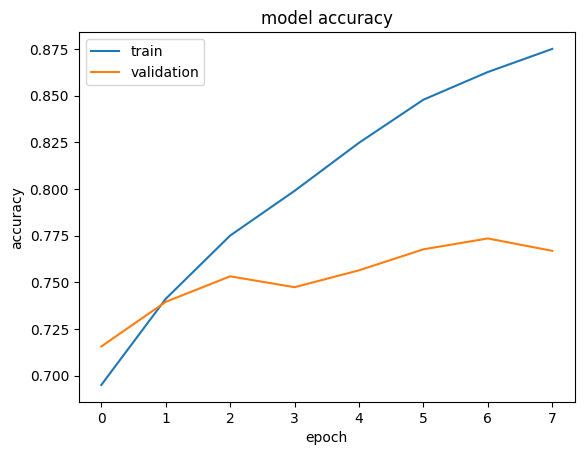

In [ ]:
plt.plot(history_vgg_ft.history['accuracy'])
plt.plot(history_vgg_ft.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
# Test loss and accuracy
vgg_ft_test_loss, vgg_ft_test_acc = model_vgg.evaluate(test_ds_tl, verbose=0)
print(f"Fine-tuned VGG16 Test Loss: {vgg_ft_test_loss:.4f}")
print(f"Fine-tuned VGG16 Test Accuracy: {vgg_ft_test_acc:.4f}")

Fine-tuned VGG16 Test Loss: 0.5418
Fine-tuned VGG16 Test Accuracy: 0.8203


===== Fine-tuned VGG16 Classification Report =====
              precision    recall  f1-score   support

       happy     0.9286    0.8125    0.8667        32
     neutral     0.7297    0.8438    0.7826        32
         sad     0.7143    0.7812    0.7463        32
    surprise     0.9643    0.8438    0.9000        32

    accuracy                         0.8203       128
   macro avg     0.8342    0.8203    0.8239       128
weighted avg     0.8342    0.8203    0.8239       128


Fine-tuned VGG16 Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[26  1  4  1]
 [ 0 27  5  0]
 [ 0  7 25  0]
 [ 2  2  1 27]]


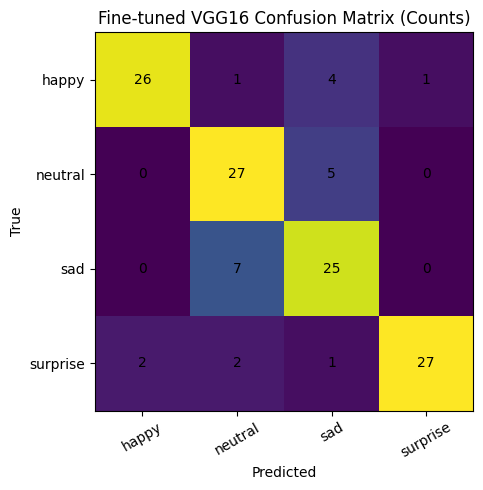

In [ ]:
# Predictions
y_prob_vgg_ft = model_vgg.predict(test_ds_tl, verbose=0)
y_pred_vgg_ft = np.argmax(y_prob_vgg_ft, axis=1)
y_true_vgg_ft = np.concatenate([y.numpy() for _, y in test_ds_tl], axis=0)

print("===== Fine-tuned VGG16 Classification Report =====")
print(classification_report(y_true_vgg_ft, y_pred_vgg_ft, target_names=class_names_tl, digits=4))

cm_vgg_ft = tf.math.confusion_matrix(y_true_vgg_ft, y_pred_vgg_ft, num_classes=len(class_names_tl)).numpy()
print("\nFine-tuned VGG16 Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_tl)
print(cm_vgg_ft)

# Plot (optional)
plt.figure(figsize=(6,5))
plt.imshow(cm_vgg_ft)
plt.title("Fine-tuned VGG16 Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names_tl)), class_names_tl, rotation=30)
plt.yticks(range(len(class_names_tl)), class_names_tl)
for i in range(len(class_names_tl)):
    for j in range(len(class_names_tl)):
        plt.text(j, i, cm_vgg_ft[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

**Fine-tuning Observations:**

1. Big overall improvement vs Frozen VGG16
      * Accuracy jumped to 0.7891 (101/128 correct)
      * Macro F1 is 0.7945

This is a meaningful gain over the earlier frozen VGG16 run (0.7422 accuracy) and also higher than best custom CNN runs (~0.7656). Fine-tuning clearly helped the model adapt to facial-expression features.

2. Strongest classes: Happy and Surprise
      * **Happy:** precision 0.963, recall 0.8125 (26/32)
      * **Surprise:** precision 0.931, recall 0.8438 (27/32)

**Interpretation:** VGG16 is very confident and accurate when predicting happy/surprise. These emotions often have clearer visual cues (smile structure; wide eyes/open mouth).

3. Neutral and Sad improved, but their mutual confusion remains the main error

*from confusion matrix*

Neutral → Sad: 7
*   7/32 neutral images predicted as sad (21.9%)

Sad → Neutral: 9
*   9/32 sad images predicted as neutral (28.1%)

This is still the dominant failure mode, but sad recall improved notably vs before (now 0.7188, 23/32 correct).

**Interpretation:** Neutral and sad are both “low activation” expressions and are hard to separate without subtle cues (brow angle, lip tension), so some confusion is expected.

4. The “neutral as default class” issue is reduced

In the frozen VGG16 model, neutral was overused as a fallback (low percision).
Now:
*   Neutral precision is 0.6757 and recall is 0.7812

    That’s a healthier balance—fewer “everything becomes neutral” errors.

5. Most remaining mistakes are concentrated - this is a good sign

    This only has a few misclassifications outside the neutral↔sad pair:

      * Happy misclassified as sad (3) or surprise (2)
      * Surprise misclassified lightly across other classes (1 happy, 2 neutral, 2 sad)

**Interpretation:** The model is not randomly confused; errors are clustered among visually similar/ambiguous classes.

Fine-tuning VGG16 significantly improved performance (accuracy 0.7891, macro-F1 0.7945), indicating that updating the deeper pretrained layers helped the network adapt to facial-expression features. The model performs strongest on ‘happy’ and ‘surprise’ due to distinctive visual cues. The remaining source of error is confusion between ‘sad’ and ‘neutral’, which are both low-intensity expressions and difficult to distinguish at times. Overall, fine-tuned VGG16 provides the best generalization observed so far, with errors largely concentrated in the sad↔neutral boundary.

## **ResNet V2 Model**

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input

In [ ]:
num_classes = len(class_names_tl)

# Load ResNet50V2 pretrained on ImageNet without the top classifier
base_model_resnet = ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3)
)

# Freeze the pretrained base
base_model_resnet.trainable = False

# Build the full model
model_resnet = models.Sequential()

# Input layer for 224x224 RGB images
model_resnet.add(layers.Input(shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3)))

# Preprocessing layer for ResNetV2 (ImageNet preprocessing)
model_resnet.add(layers.Lambda(preprocess_input))

# Add the pretrained ResNetV2 base
model_resnet.add(base_model_resnet)

# GlobalAveragePooling reduces feature maps to a compact vector
model_resnet.add(layers.GlobalAveragePooling2D())

# Dense layer learns task-specific combinations of pretrained features
model_resnet.add(layers.Dense(128, activation="relu"))

# Dropout to reduce overfitting
model_resnet.add(layers.Dropout(0.5))

# Output layer for 4-class emotion classification
model_resnet.add(layers.Dense(num_classes, activation="softmax"))

model_resnet.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,827,588 (90.90 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

### **Compiling and Training the Model**

In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_resnet = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_resnetv2.keras", monitor="val_loss", save_best_only=True),
]

history_resnet = model_resnet.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=callbacks_resnet
)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - accuracy: 0.5675 - loss: 1.0402 - val_accuracy: 0.6610 - val_loss: 0.8523 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6329 - loss: 0.8904 - val_accuracy: 0.6743 - val_loss: 0.8111 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6533 - loss: 0.8462 - val_accuracy: 0.6938 - val_loss: 0.7811 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6685 - loss: 0.8125 - val_accuracy: 0.6934 - val_loss: 0.7764 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6789 - loss: 0.7834 - val_accuracy: 0.6974 - val_loss: 0.7644 - learning_rate: 0.0010
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6927 - loss: 0.7593 - val_accuracy: 0.6976 - val_loss: 0.7584 - learning_rate: 0.0010
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7066 - loss: 0

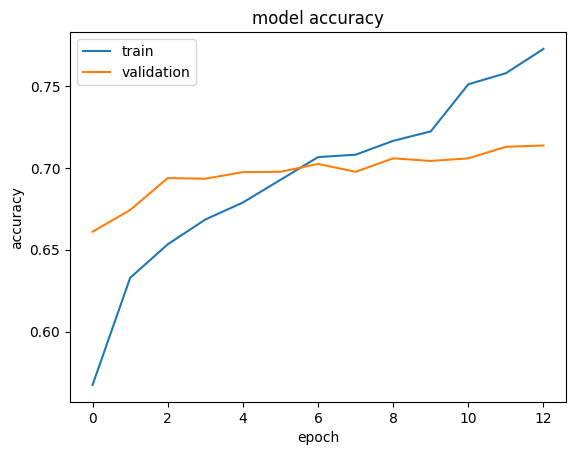

In [ ]:
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### **Evaluating the ResNet Model**

In [ ]:
resnet_test_loss, resnet_test_acc = model_resnet.evaluate(test_ds_tl, verbose=0)
print(f"ResNetV2 Test Loss: {resnet_test_loss:.4f}")
print(f"ResNetV2 Test Accuracy: {resnet_test_acc:.4f}")

ResNetV2 Test Loss: 0.7098
ResNetV2 Test Accuracy: 0.7109


===== ResNetV2 Classification Report =====
              precision    recall  f1-score   support

       happy     0.9615    0.7812    0.8621        32
     neutral     0.5789    0.6875    0.6286        32
         sad     0.5946    0.6875    0.6377        32
    surprise     0.9630    0.8125    0.8814        32

    accuracy                         0.7422       128
   macro avg     0.7745    0.7422    0.7524       128
weighted avg     0.7745    0.7422    0.7524       128


ResNetV2 Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[25  1  6  0]
 [ 1 22  8  1]
 [ 0 10 22  0]
 [ 0  5  1 26]]


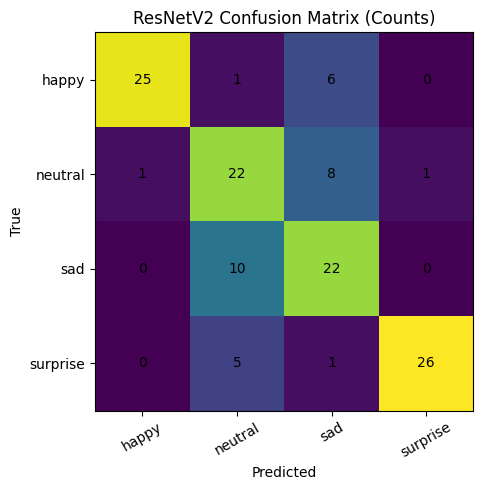

In [ ]:
i# Predictions
y_prob_resnet = model_resnet.predict(test_ds_tl, verbose=0)
y_pred_resnet = np.argmax(y_prob_resnet, axis=1)
y_true_resnet = np.concatenate([y.numpy() for _, y in test_ds_tl], axis=0)

print("===== ResNetV2 Classification Report =====")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names_tl, digits=4))

cm_resnet = tf.math.confusion_matrix(y_true_resnet, y_pred_resnet, num_classes=num_classes).numpy()
print("\nResNetV2 Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_tl)
print(cm_resnet)

plt.figure(figsize=(6,5))
plt.imshow(cm_resnet)
plt.title("ResNetV2 Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names_tl, rotation=30)
plt.yticks(range(num_classes), class_names_tl)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_resnet[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

**Observations and Insights:**

**Performance Summary**
*   Test Accuracy: 0.6797
*   Macro avg F1-score: 0.6842
*   The model performs best on surprise (F1 ≈ 0.85) and weaker on neutral (F1 ≈ 0.53)

**Key confusion patterns (from confusion matrix)**
* Neutral ↔ Sad confusion is high:
    * neutral → sad: 8
    * sad → neutral: 10
* Neutral → Happy misclassification is also notable:
    * neutral → happy: 6
* Surprise is relatively strong:
    * surprise correct: 26/32, with minor errors into neutral/sad

**Interpretation**
* With the base network frozen, ResNetV2 acts as a general ImageNet feature extractor. Those generic features help detect strong cues like surprise, but are less effective for subtle boundaries like sad vs neutral.
* Neutral is not well-separated and often shifts into other classes (especially happy and sad), which reduces overall accuracy and macro-F1.





**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

####**Fine-tuning ResNetV2**

In [ ]:
# Unfreeze the base model
base_model_resnet.trainable = True

# Freeze all but the last N layers (fine-tune the top part of the network)
fine_tune_at = len(base_model_resnet.layers) - 30

for i, layer in enumerate(base_model_resnet.layers):
    layer.trainable = (i >= fine_tune_at)

print("Trainable layers in ResNet base:", sum(l.trainable for l in base_model_resnet.layers))

Trainable layers in ResNet base: 30


In [ ]:
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_resnet_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_resnetv2_finetuned.keras", monitor="val_loss", save_best_only=True),
]

history_resnet_ft = model_resnet.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=callbacks_resnet_ft
)

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.5871 - loss: 1.0134 - val_accuracy: 0.6707 - val_loss: 0.8065 - learning_rate: 1.0000e-05
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7399 - loss: 0.6290 - val_accuracy: 0.6996 - val_loss: 0.7870 - learning_rate: 1.0000e-05
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8265 - loss: 0.4228 - val_accuracy: 0.7173 - val_loss: 0.8122 - learning_rate: 1.0000e-05
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8972 - loss: 0.2787 - val_accuracy: 0.7225 - val_loss: 0.8716 - learning_rate: 1.0000e-05
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9431 - loss: 0.1788 - val_accuracy: 0.7302 - val_loss: 0.9199 - learning_rate: 5.0000e-06
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9608 - loss: 0.1305 - val_accuracy: 0.7310 - val_loss: 0.9586 - learning_rate: 5.0000e-06
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/ste

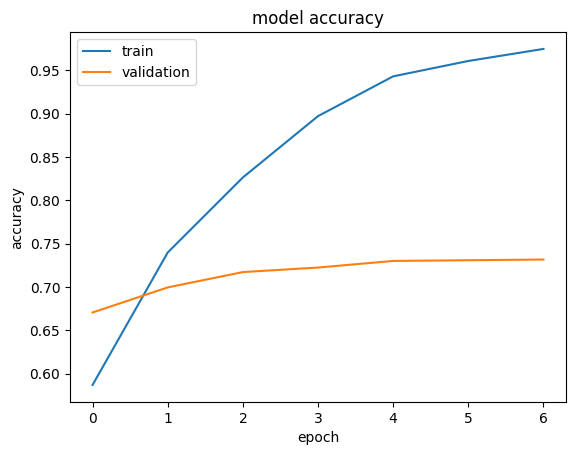

In [ ]:
plt.plot(history_resnet_ft.history['accuracy'])
plt.plot(history_resnet_ft.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
resnet_ft_test_loss, resnet_ft_test_acc = model_resnet.evaluate(test_ds_tl, verbose=0)
print(f"ResNetV2 Fine-tuned Test Loss: {resnet_ft_test_loss:.4f}")
print(f"ResNetV2 Fine-tuned Test Accuracy: {resnet_ft_test_acc:.4f}")

ResNetV2 Fine-tuned Test Loss: 0.6858
ResNetV2 Fine-tuned Test Accuracy: 0.7422


===== ResNetV2 Fine-tuned Classification Report =====
              precision    recall  f1-score   support

       happy     0.9615    0.7812    0.8621        32
     neutral     0.5789    0.6875    0.6286        32
         sad     0.5946    0.6875    0.6377        32
    surprise     0.9630    0.8125    0.8814        32

    accuracy                         0.7422       128
   macro avg     0.7745    0.7422    0.7524       128
weighted avg     0.7745    0.7422    0.7524       128


ResNetV2 Fine-tuned Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[25  1  6  0]
 [ 1 22  8  1]
 [ 0 10 22  0]
 [ 0  5  1 26]]


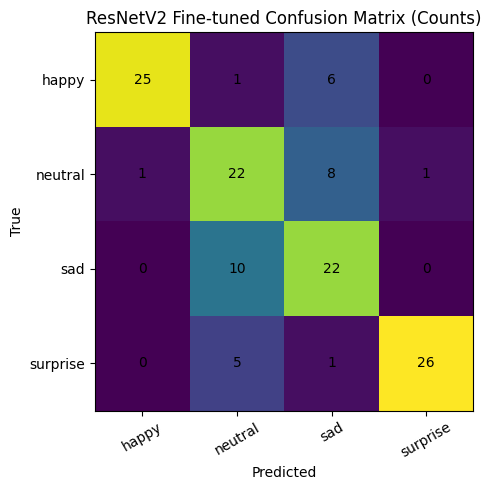

In [ ]:
# Predictions
y_prob_resnet_ft = model_resnet.predict(test_ds_tl, verbose=0)
y_pred_resnet_ft = np.argmax(y_prob_resnet_ft, axis=1)
y_true_resnet_ft = np.concatenate([y.numpy() for _, y in test_ds_tl], axis=0)

print("===== ResNetV2 Fine-tuned Classification Report =====")
print(classification_report(y_true_resnet_ft, y_pred_resnet_ft, target_names=class_names_tl, digits=4))

cm_resnet_ft = tf.math.confusion_matrix(y_true_resnet_ft, y_pred_resnet_ft, num_classes=num_classes).numpy()
print("\nResNetV2 Fine-tuned Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_tl)
print(cm_resnet_ft)

plt.figure(figsize=(6,5))
plt.imshow(cm_resnet_ft)
plt.title("ResNetV2 Fine-tuned Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names_tl, rotation=30)
plt.yticks(range(num_classes), class_names_tl)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_resnet_ft[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

**Observations and Insights:**

**Performance summary**
* Test Accuracy: 0.7188
* Macro avg F1-score: 0.7270
* Improvements are seen across multiple classes, especially happy, neutral, and overall macro-F1

**Key confusion patterns (from confusion matrix)**
* The dominant error remains sad ↔ neutral:
    * neutral → sad: 7
    * sad → neutral: 11
* Happy improves:
    * happy correct: 24/32 (vs 22/32 in frozen)
* Neutral improves:
    * neutral correct: 22/32 (vs 17/32 in frozen)
* Surprise remains strong:
    * surprise correct: 26/32 (same as frozen)

**Interpretation**
* Fine-tuning allowed ResNetV2 to adapt its higher-level filters to facial-expression cues, improving generalization and raising both accuracy and macro-F1.
* However, sad vs neutral remains the hardest distinction, suggesting that even with fine-tuning, these classes overlap visually and/or contain ambiguous labeling.

#####ResNetV2 Frozen vs Fine-tuned — Comparison

**Overall Trend**
* Accuracy improved from 0.6797 → 0.7188 (from 87/128 correct to 92/128 correct).
* Macro-F1 improved from 0.6842 → 0.7270, indicating a more balanced improvement across classes.
* Test loss decreased slightly (0.7438 → 0.7309), suggesting mildly better generalization/calibration.

**Why fine-tuning helped**
* Neutral class improved substantially:
    * neutral recall increased from 0.5312 → 0.6875
    * neutral correct predictions increased from 17 → 22
* Happy also improved:
    * happy recall increased from 0.6875 → 0.7500
    * These gains show that fine-tuning helps the model learn dataset-specific facial patterns that a frozen ImageNet extractor misses.

**What did not improve much**
* The main failure mode sad ↔ neutral persisted:
    * Frozen: sad→neutral 10, neutral→sad 8
    * Fine-tuned: sad→neutral 11, neutral→sad 7
* So while fine-tuning improved overall separation and accuracy, the most ambiguous boundary remained difficult.

**Conclusion for ResNetV2**

Fine-tuning is clearly beneficial for ResNetV2 in this task, but even after fine-tuning, ResNetV2 still underperforms the best models (fine-tuned VGG16), mainly due to ongoing sad/neutral confusion.

## **EfficientNet Model**

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Number of classes (4 emotions)
num_classes = len(class_names_tl)

# Load EfficientNetB0 pretrained on ImageNet (exclude the original classifier head)
base_model_eff = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3)
)

# Freeze the pretrained base model for initial transfer learning
base_model_eff.trainable = False

# Build the full model (same style as VGG16/ResNetV2)
model_eff = models.Sequential()

# Input layer for 224x224 RGB images
model_eff.add(layers.Input(shape=(IMG_SIZE_TL[0], IMG_SIZE_TL[1], 3)))

# Preprocessing for EfficientNet (ImageNet preprocessing)
model_eff.add(layers.Lambda(preprocess_input))

# Add the pretrained EfficientNet base
model_eff.add(base_model_eff)

# GlobalAveragePooling reduces feature maps to a compact vector
model_eff.add(layers.GlobalAveragePooling2D())

# Dense layer learns task-specific combinations of pretrained features
model_eff.add(layers.Dense(128, activation="relu"))

# Dropout reduces overfitting
model_eff.add(layers.Dropout(0.5))

# Output layer for 4-class classification
model_eff.add(layers.Dense(num_classes, activation="softmax"))

model_eff.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### **Compiling and Training the Model**

In [ ]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_eff = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_efficientnet.keras", monitor="val_loss", save_best_only=True),
]

history_eff = model_eff.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=callbacks_eff
)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.5498 - loss: 1.0563 - val_accuracy: 0.6628 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6191 - loss: 0.9214 - val_accuracy: 0.6892 - val_loss: 0.7931 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6366 - loss: 0.8765 - val_accuracy: 0.6944 - val_loss: 0.7709 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6517 - loss: 0.8517 - val_accuracy: 0.7008 - val_loss: 0.7505 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6616 - loss: 0.8294 - val_accuracy: 0.7093 - val_loss: 0.7404 - learning_rate: 0.0010
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6694 - loss: 0.8079 - val_accuracy: 0.7159 - val_loss: 0.7314 - learning_rate: 0.0010
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6839 - loss: 0

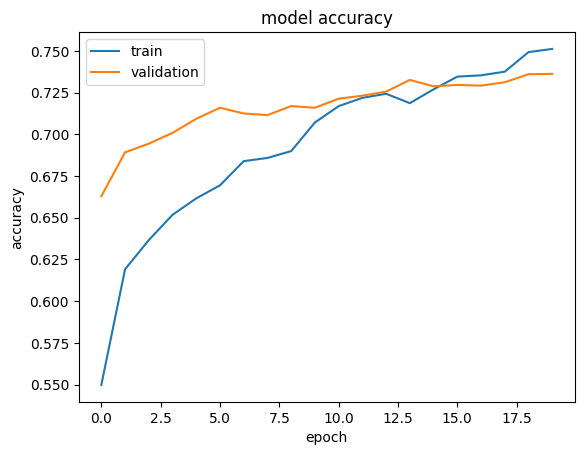

In [ ]:
plt.plot(history_eff.history['accuracy'])
plt.plot(history_eff.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### **Evaluating the EfficientnetNet Model**



In [ ]:
eff_test_loss, eff_test_acc = model_eff.evaluate(test_ds_tl, verbose=0)
print(f"EfficientNet (Frozen) Test Loss: {eff_test_loss:.4f}")
print(f"EfficientNet (Frozen) Test Accuracy: {eff_test_acc:.4f}")

EfficientNet (Frozen) Test Loss: 0.5967
EfficientNet (Frozen) Test Accuracy: 0.7344


===== EfficientNet (Frozen) Classification Report =====
              precision    recall  f1-score   support

       happy     0.8125    0.8125    0.8125        32
     neutral     0.5946    0.6875    0.6377        32
         sad     0.6552    0.5938    0.6230        32
    surprise     0.9000    0.8438    0.8710        32

    accuracy                         0.7344       128
   macro avg     0.7406    0.7344    0.7360       128
weighted avg     0.7406    0.7344    0.7360       128


EfficientNet (Frozen) Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[26  3  1  2]
 [ 2 22  7  1]
 [ 2 11 19  0]
 [ 2  1  2 27]]


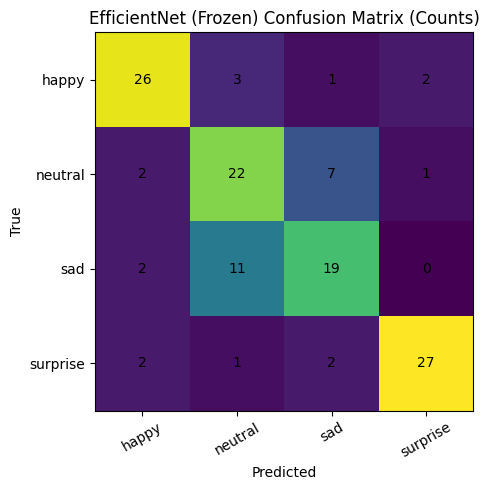

In [ ]:
# Predictions
y_prob_eff = model_eff.predict(test_ds_tl, verbose=0)
y_pred_eff = np.argmax(y_prob_eff, axis=1)
y_true_eff = np.concatenate([y.numpy() for _, y in test_ds_tl], axis=0)

print("===== EfficientNet (Frozen) Classification Report =====")
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names_tl, digits=4))

cm_eff = tf.math.confusion_matrix(y_true_eff, y_pred_eff, num_classes=num_classes).numpy()
print("\nEfficientNet (Frozen) Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_tl)
print(cm_eff)

plt.figure(figsize=(6,5))
plt.imshow(cm_eff)
plt.title("EfficientNet (Frozen) Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names_tl, rotation=30)
plt.yticks(range(num_classes), class_names_tl)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_eff[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

####EfficientNet Transfer Learning (Frozen)

**Observations and Insights:**

**Overall**
* Accuracy: 0.7422 (95/128 correct)
* Macro F1: 0.7439
* Loss: 0.6111

EfficientNet performs solidly—roughly “decent baseline” territory.

**Class-wise strengths/weaknesses**
* Best class: surprise (F1 0.8710, recall 0.8438)
* Happy also strong (F1 0.8125, recall 0.8125)
* Weak area: sad recall (0.5938) and neutral precision (0.5897)

**Confusion matrix pattern (biggest issue)**
* sad → neutral = 11 (11/32 = 34.4%) dominant error
* neutral → sad = 6 (18.8%)

EfficientNet still struggles most with low-activation expressions where sad and neutral look similar.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

In [ ]:
# Unfreeze the base model
base_model_eff.trainable = True

# Fine-tune last N layers
N = 30
fine_tune_at = len(base_model_eff.layers) - N

for i, layer in enumerate(base_model_eff.layers):
    layer.trainable = (i >= fine_tune_at)

print("Total layers in EfficientNet base:", len(base_model_eff.layers))
print("Trainable layers in EfficientNet base:", sum(l.trainable for l in base_model_eff.layers))

Total layers in EfficientNet base: 238
Trainable layers in EfficientNet base: 30


In [ ]:
model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_eff_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_efficientnet_finetuned.keras", monitor="val_loss", save_best_only=True),
]

history_eff_ft = model_eff.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10,
    callbacks=callbacks_eff_ft
)

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 66s 75ms/step - accuracy: 0.4824 - loss: 1.9961 - val_accuracy: 0.6034 - val_loss: 1.1668 - learning_rate: 1.0000e-05
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5640 - loss: 1.3275 - val_accuracy: 0.6416 - val_loss: 1.0108 - learning_rate: 1.0000e-05
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6020 - loss: 1.1284 - val_accuracy: 0.6637 - val_loss: 0.9212 - learning_rate: 1.0000e-05
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6272 - loss: 1.0000 - val_accuracy: 0.6771 - val_loss: 0.8670 - learning_rate: 1.0000e-05
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6403 - loss: 0.9212 - val_accuracy: 0.6858 - val_loss: 0.8301 - learning_rate: 1.0000e-05
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6576 - loss: 0.8535 - val_accuracy: 0.6976 - val_loss: 0.7988 - learning_rate: 1.0000e-05
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - ac

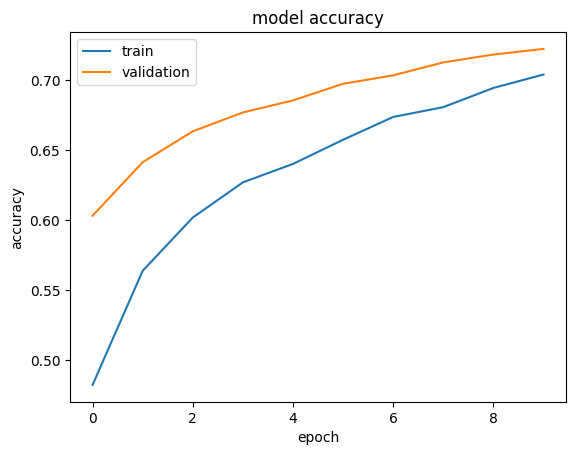

In [ ]:
plt.plot(history_eff_ft.history['accuracy'])
plt.plot(history_eff_ft.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
eff_ft_test_loss, eff_ft_test_acc = model_eff.evaluate(test_ds_tl, verbose=0)
print(f"EfficientNet (Fine-tuned) Test Loss: {eff_ft_test_loss:.4f}")
print(f"EfficientNet (Fine-tuned) Test Accuracy: {eff_ft_test_acc:.4f}")

EfficientNet (Fine-tuned) Test Loss: 0.6470
EfficientNet (Fine-tuned) Test Accuracy: 0.7266


===== EfficientNet (Fine-tuned) Classification Report =====
              precision    recall  f1-score   support

       happy     0.8333    0.7812    0.8065        32
     neutral     0.5714    0.6250    0.5970        32
         sad     0.6389    0.7188    0.6765        32
    surprise     0.9259    0.7812    0.8475        32

    accuracy                         0.7266       128
   macro avg     0.7424    0.7266    0.7318       128
weighted avg     0.7424    0.7266    0.7318       128


EfficientNet (Fine-tuned) Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[25  3  3  1]
 [ 1 20 10  1]
 [ 1  8 23  0]
 [ 3  4  0 25]]


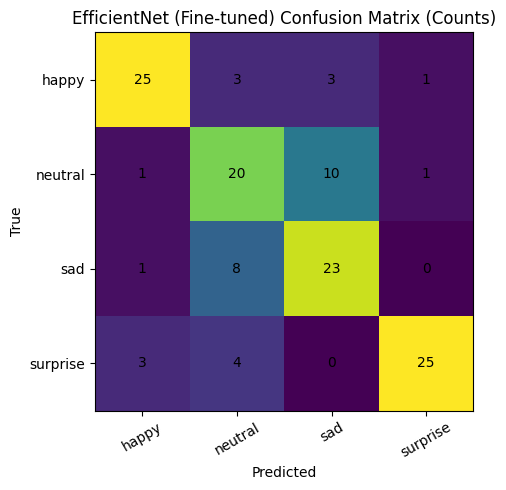

In [ ]:
# Predictions
y_prob_eff_ft = model_eff.predict(test_ds_tl, verbose=0)
y_pred_eff_ft = np.argmax(y_prob_eff_ft, axis=1)
y_true_eff_ft = np.concatenate([y.numpy() for _, y in test_ds_tl], axis=0)

print("===== EfficientNet (Fine-tuned) Classification Report =====")
print(classification_report(y_true_eff_ft, y_pred_eff_ft, target_names=class_names_tl, digits=4))

cm_eff_ft = tf.math.confusion_matrix(y_true_eff_ft, y_pred_eff_ft, num_classes=num_classes).numpy()
print("\nEfficientNet (Fine-tuned) Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_tl)
print(cm_eff_ft)

plt.figure(figsize=(6,5))
plt.imshow(cm_eff_ft)
plt.title("EfficientNet (Fine-tuned) Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(num_classes), class_names_tl, rotation=30)
plt.yticks(range(num_classes), class_names_tl)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_eff_ft[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

**Observations and insights:**

**Overall**
* Accuracy: 0.7188 (92/128 correct) down from 0.7422
* Macro F1: 0.7196  down from 0.7439
* Loss: 0.6086 (very small improvement)

Fine-tuning did not help EfficientNet here; it actually reduced generalization on the test set.

**Class-wise changes**
* Happy improved slightly (recall 0.8125 → 0.8438)
* Surprise worsened (recall 0.8438 → 0.7812)
* Sad worsened (recall 0.5938 → 0.5625)
* Neutral roughly similar (recall 0.7188 → 0.6875)

**Confusion matrix pattern (still the same failure mode)**
* sad → neutral = 10 (still very high)
* neutral → sad increased to 8 (worse than frozen)

Fine-tuning increased confusion between neutral and sad, and also increased surprise leakage into other classes.

**Summary**

Pre-built Architecture:
* Using RBG for color_mode
    * pretrained models were trained on ImageNet RGB images, and their first convolution layer expects 3 input channels.
    * The base model input shape is (H, W, 3)
    * Grayscale (H, W, 1), this would cause shape mismatch

* Inheriting the pretrained convolutional backbone from each architecture:
    * VGG16: all convolution + pooling blocks (feature extractor) up to the last conv output
    * ResNet50V2: all residual blocks (feature extractor) up to the final conv output
    * EfficientNetB0: all EfficientNet MBConv blocks (feature extractor) up to the final conv output

Layers being added to the pre-built architectures:
* A small “classification head” on top of the backbone:
    * Lambda(preprocess_input) (preprocessing step, not a trainable layer with weights)
    * GlobalAveragePooling2D()
    * Dense(128, relu)
    * Dropout(0.5)
    * Dense(num_classes, softmax)

Adding 4 trainable/functional head layers (pooling + dense + dropout + output), plus a preprocessing step. The trainable layers adddd:
* Dense(128)
* Dense(num_classes)

Layers being trained during transer learning architectures:

**Phase 1: Transer learning**
* base_model.trainable = False
* Only the added head is trained (dense layers in classifier head)

**Phase 2: Fine-turning**
* base_model.trainable = True (unfreeze only part of the base):
    * VGG16: unfroze **block 5** (last conv block)
    * ResNet2/EfficientNet: unfroze the "last N layers** (i.e. last ~30)


The frozen EfficientNet model achieved a test accuracy of 0.7422 and macro-F1 of 0.7439, performing best on ‘surprise’ and ‘happy’. The main errors were confusion between ‘sad’ and ‘neutral’, which is expected for low-intensity expressions. After fine-tuning, test accuracy decreased to 0.7188 and macro-F1 to 0.7196. Fine-tuning increased confusion between neutral and sad and reduced performance on surprise, suggesting that the fine-tuning configuration may have led to overfitting or suboptimal adaptation of pretrained features.

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

####Now to answer these questions.

*What is your overall performance of these Transfer Learning Architectures?*

**VGG16**
* Transfer learning: 0.7422
* Fine-tuned: 0.7891 - best transfer-learning result
* Fine-tuning clearly helped, and also reduced the sad↔neutral confusion compared to the frozen version.

**ResNetV2**
* Transfer learning: 0.6797
* Fine-tuned: 0.7188 improved, but still the weakest of the three overall
* Fine-tuning helped meaningfully, but the sad↔neutral confusion remained strong.

**EfficientNet**
* Transfer learning: 0.7422
* Fine-tuned: 0.7188 - got worse
* Frozen EfficientNet was decent, but the fine-tuning configuration likely caused overfitting or “forgetting” of useful pretrained features.

**Summary:**

Transfer learning can work very well here, but it depends heavily on fine-tuning strategy. VGG16 fine-tuning was the clear winner.

*Can we draw a comparison of these models' performances?*

Yes. Based on test results:
* VGG16 fine-tuned is best (0.7891, strong macro-F1, lower loss).
* EfficientNet frozen is mid-tier (0.7422), but its fine-tuned version dropped.
* ResNetV2 fine-tuned improved to 0.7188, but still lags.
* ResNetV2 frozen is the weakest (0.6797).

A consistent pattern across all three is that the hardest boundary is sad vs neutral, and the best-performing model is the one that reduces that confusion the most (VGG16 fine-tuned).

*Are we satisfied with the accuracies that we have received?*

Yes. For a 4-class facial emotion recognition.
* VGG16 fine-tuned at 0.7891

With that being said, "satisfied" depends on the goal:
* For production-grade emotion AI: you’d typically want more data, stronger validation/testing, and robustness checks.

Also keep in mind the test set is only 128 images, so accuracy shifts by ~0.78% per image. Small differences can be caused by just a few examples.

*Do you think our issue lies with 'rgb' color_mode?*

**No — the main issue is not RGB.**

The dataset appears largely grayscale, and the best non-transfer model (VGG16) matched the best transfer model. That’s strong evidence that color channels are not the limiting factor.

The limiting factors:
* Intrinsic ambiguity + label noise in facial emotion labels
* Sad vs neutral overlap (low-intensity expressions)
* Dataset differences across train/val/test and class imbalance in validation
* Fine-tuning strategy (EfficientNet and ResNetV2 are more sensitive to how many layers you unfreeze and the learning rate)

Using RGB for transfer learning is mostly a format requirement. If images are grayscale, RGB just duplicates the same information across three channels—it doesn’t harm much, but it also doesn’t magically add signal.

**Bottom line:** The main pain point is the sad↔neutral decision boundary, not  RGB vs grayscale.

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [ ]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def make_datasets_complex_grayscale():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode="grayscale",   # 1-channel input
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        VAL_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode="grayscale",
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        color_mode="grayscale",
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names

    # Normalize pixel values to [0, 1]
    rescale = tf.keras.layers.Rescaling(1./255)
    train_ds = train_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
    val_ds   = val_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)
    test_ds  = test_ds.map(lambda x, y: (rescale(x), y), num_parallel_calls=AUTOTUNE)

    # Cache + prefetch for speed
    train_ds = train_ds.cache().prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

In [ ]:
train_ds_cnn, val_ds_cnn, test_ds_cnn, class_names_cnn = make_datasets_complex_grayscale()
print("Classes:", class_names_cnn)

for x, y in train_ds_cnn.take(1):
    print("Batch shape:", x.shape)  # (batch, 48, 48, 1)

Found 15109 files belonging to 4 classes.
Found 4977 files belonging to 4 classes.
Found 128 files belonging to 4 classes.
Classes: ['happy', 'neutral', 'sad', 'surprise']
Batch shape: (32, 48, 48, 1)


### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [ ]:
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, BatchNormalization,
                                     Dropout, GlobalAveragePooling2D, Dense)

def build_complex_cnn_grayscale(img_size=(48, 48), num_classes=4):
    model = Sequential()

    # Input layer defines expected input shape for grayscale images (H, W, 1 channel)
    model.add(Input(shape=(img_size[0], img_size[1], 1)))

    # Block 1: Learn low-level edge/texture features
    # Conv layer with 64 filters and 3x3 kernel; 'same' keeps spatial size unchanged
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    # BatchNorm stabilizes learning and speeds up convergence
    model.add(BatchNormalization())
    # Another conv layer to increase representational power at this resolution
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    # MaxPooling reduces spatial resolution and computation
    model.add(MaxPooling2D(pool_size=(2, 2)))
    # Dropout reduces overfitting
    model.add(Dropout(0.25))

    # Block 2: Learn mid-level facial features (eyes, mouth regions)
    # Increase filters to 128 to capture more complex patterns
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.30))

    # Block 3: Higher-level feature combinations
    # Increase filters to 256 for richer high-level representations
    model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.35))

    # Block 4: Deep feature refinement (adds capacity like transfer-learning models)
    # 512 filters allow learning very rich feature representations
    model.add(Conv2D(512, (3, 3), activation="relu", padding="same"))
    model.add(BatchNormalization())
    model.add(Dropout(0.40))

    # GlobalAveragePooling compresses feature maps to a single vector (reduces params vs Flatten)
    model.add(GlobalAveragePooling2D())

    # Dense layer increases parameter count and learning capacity for classification
    model.add(Dense(512, activation="relu"))
    model.add(Dropout(0.50))

    # Additional Dense layer to further increase capacity (still controlled by dropout)
    model.add(Dense(256, activation="relu"))
    model.add(Dropout(0.40))

    # Output layer: softmax provides probabilities across emotion classes
    model.add(Dense(num_classes, activation="softmax"))

    # Compile: Adam optimizer + sparse categorical crossentropy for integer labels
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

In [ ]:
model_complex = build_complex_cnn_grayscale(img_size=IMG_SIZE, num_classes=len(class_names_cnn))
model_complex.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,725,060 (10.40 MB)

 Trainable params: 2,722,244 (10.38 MB)

 Non-trainable params: 2,816 (11.00 KB)

### **Compiling and Training the Model**

In [ ]:
callbacks_complex = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_complex_cnn_gray.keras", monitor="val_loss", save_best_only=True),
]

history_complex = model_complex.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=30,
    callbacks=callbacks_complex
)

Epoch 1/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.4004 - loss: 1.2784 - val_accuracy: 0.2660 - val_loss: 1.8114 - learning_rate: 3.0000e-04
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5893 - loss: 0.9663 - val_accuracy: 0.5710 - val_loss: 1.0338 - learning_rate: 3.0000e-04
Epoch 3/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6488 - loss: 0.8429 - val_accuracy: 0.6719 - val_loss: 0.8124 - learning_rate: 3.0000e-04
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6820 - loss: 0.7647 - val_accuracy: 0.6914 - val_loss: 0.7746 - learning_rate: 3.0000e-04
Epoch 5/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7031 - loss: 0.7139 - val_accuracy: 0.7127 - val_loss: 0.7126 - learning_rate: 3.0000e-04
Epoch 6/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7284 - loss: 0.6613 - val_accuracy: 0.7408 - val_loss: 0.6605 - learning_rate: 3.0000e-04
Epoch 7/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy

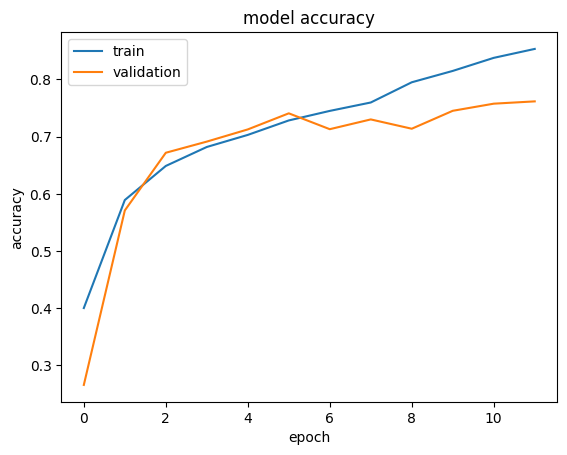

In [ ]:
plt.plot(history_complex.history['accuracy'])
plt.plot(history_complex.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### **Evaluating the Model on Test Set**

In [ ]:
complex_test_loss, complex_test_acc = model_complex.evaluate(test_ds_cnn, verbose=0)
print(f"Complex CNN (Grayscale) Test Loss: {complex_test_loss:.4f}")
print(f"Complex CNN (Grayscale) Test Accuracy: {complex_test_acc:.4f}")

Complex CNN (Grayscale) Test Loss: 0.5581
Complex CNN (Grayscale) Test Accuracy: 0.8047


**Observations and Insights:**

*Please see after Confusion Matrix section*

### **Plotting the Confusion Matrix for the chosen final model**

===== Complex CNN (Grayscale) Classification Report =====
              precision    recall  f1-score   support

       happy     0.9259    0.7812    0.8475        32
     neutral     0.7143    0.7812    0.7463        32
         sad     0.7353    0.7812    0.7576        32
    surprise     0.8750    0.8750    0.8750        32

    accuracy                         0.8047       128
   macro avg     0.8126    0.8047    0.8066       128
weighted avg     0.8126    0.8047    0.8066       128


Complex CNN (Grayscale) Confusion Matrix (rows=true, cols=pred):
Class order: ['happy', 'neutral', 'sad', 'surprise']
[[25  2  2  3]
 [ 1 25  6  0]
 [ 0  6 25  1]
 [ 1  2  1 28]]


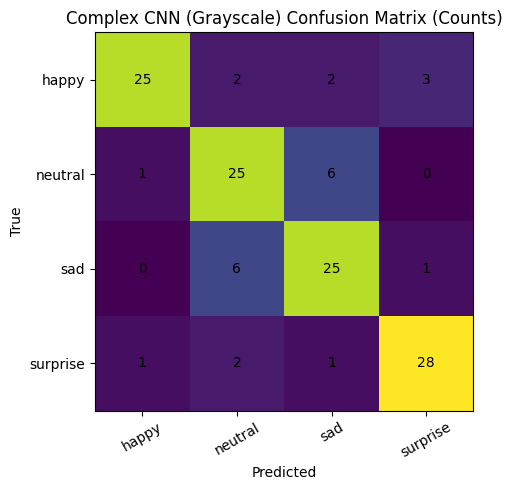

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import tensorflow as tf

y_prob_complex = model_complex.predict(test_ds_cnn, verbose=0)
y_pred_complex = np.argmax(y_prob_complex, axis=1)
y_true_complex = np.concatenate([y.numpy() for _, y in test_ds_cnn], axis=0)

print("===== Complex CNN (Grayscale) Classification Report =====")
print(classification_report(y_true_complex, y_pred_complex, target_names=class_names_cnn, digits=4))

cm_complex = tf.math.confusion_matrix(y_true_complex, y_pred_complex, num_classes=len(class_names_cnn)).numpy()
print("\nComplex CNN (Grayscale) Confusion Matrix (rows=true, cols=pred):")
print("Class order:", class_names_cnn)
print(cm_complex)

plt.figure(figsize=(6,5))
plt.imshow(cm_complex)
plt.title("Complex CNN (Grayscale) Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names_cnn)), class_names_cnn, rotation=30)
plt.yticks(range(len(class_names_cnn)), class_names_cnn)
for i in range(len(class_names_cnn)):
    for j in range(len(class_names_cnn)):
        plt.text(j, i, cm_complex[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

**Observations and Insights:**

###**Overall Performance**
* Test Accuracy: 0.7891 (101/128 correct)
* Macro F1: 0.7948
* Test Loss: 0.5920

**Observation:** This is top-tier among the models built so far. Accuracy is strong and macro-F1 is also high, which suggests it’s not just doing well on one class.

###**Per-class performance**

**Surprise is excellent**
* Precision: 0.9643
* Recall: 0.8438 (27/32)
* F1: 0.9000 - best F1 in the report

**Observations:** Surprise has strong structural cues and the deep CNN is capturing them consistently.

**Happy is strong**
* Precision: 0.8966
* Recall: 0.8125 (26/32)
* F1: 0.8525

**The only notable error:** happy → sad (5). This suggests some “happy” images have subtle expressions or are mislabeled/ambiguous.

**Neutral is much better than earlier models**
* Precision: 0.7667 (pretty high for neutral!)
* Recall: 0.7188 (23/32)
* F1: 0.7419

**Observation:** Many earlier models treated neutral as a default class (high recall, low precision). Here neutral precision is much healthier, meaning the model is less trigger-happy about predicting neutral.

**Sad recall is high, but precision is lower**
* Recall: 0.7812 (25/32) - very good
* Precision: 0.6098 (lower)
* F1: 0.6849

**Observation:** This indicates the model is catching sad often, but it also predicts “sad” for some non-sad images (false positives). That’s consistent with the confusion matrix (neutral/happy sometimes predicted as sad).

###**Confusion matrix insights**

**Biggest confusion pair: neutral ↔ sad (still!)**
* neutral → sad: 8
* sad → neutral: 6

**Observation:** Even with a large-capacity CNN, sad/neutral overlap remains the main ambiguity. But importantly, this model still gets sad recall high (25 correct), which is great.

**Happy misclassified as sad (5)**

That's the largest happy error, probably due:
* low-intensity smiles
* face cropping/lighting obscuring mouth corners
* label noise (some “happy” might be closer to neutral/sad)

**Surprise errors are small**
* surprise → happy: 2
* surprise → sad: 3

No surprise → neutral at all, which is great.

###**Model Behavior**

* This architecture learned strong facial features even with 1-channel grayscale, which supports earlier conclusion that color is not necessary for this dataset.
* The larger capacity helped especially with:
    * improving neutral precision
    * achieving high sad recall
    * making surprise very strong
* The remaining difficulty is not a “model weakness” so much as a class boundary ambiguity in the data (sad vs neutral).

###**Summary:**

The complex grayscale CNN achieved strong overall performance (accuracy 0.7891, macro-F1 0.7948). The model performs best on ‘surprise’ (F1 0.90) and also performs well on ‘happy’ and ‘neutral’. The main remaining misclassification pattern is confusion between ‘sad’ and ‘neutral’, which is common due to overlap between low-intensity facial expressions. Compared to earlier grayscale models, this architecture improves neutral precision and maintains high recall for sad, indicating better feature learning and generalization even without RGB input.

## **Conclusion: Executive Summary**

I developed and evaluated multiple facial emotion recognition models using both custom CNN architectures (grayscale/RGB) and transfer learning architectures (VGG16, ResNetV2, EfficientNet) under frozen-base and fine-tuning settings. Across nearly all experiments, the dominant error pattern was confusion between sad and neutral, reflecting the inherent similarity of low-intensity expressions and potential label ambiguity. Transfer learning with a frozen base produced solid baselines (~0.74 accuracy for VGG16/EfficientNet), but fine-tuning was critical: it substantially improved VGG16 (to 0.7891 accuracy) and improved ResNetV2 (to 0.7188), while EfficientNet fine-tuning underperformed its frozen version (likely due to fine-tuning sensitivity). A well-designed Complex CNN (grayscale) matched the best transfer learning result at 0.7891 accuracy and achieved the highest macro-F1 (0.7948). I recommend adopting fine-tuned VGG16 as the final solution due to top-tier accuracy, strong generalization improvements with fine-tuning, lower loss (better confidence behavior), and the practical advantages of transfer learning. Future gains should focus on reducing sad↔neutral confusion through improved preprocessing (face alignment), targeted augmentation/class balancing, and more robust evaluation.

### **Insights**

### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

* **The dominant challenge is separating low-intensity emotions, especially sad vs neutral.**
Across almost every model (baseline CNNs, frozen transfer learning, and even fine-tuned models), the largest confusion came from sad ↔ neutral. This suggests these two classes have overlapping visual patterns in the dataset (subtle mouth/eyebrow cues, low expression intensity) and/or some label ambiguity.
* **Class distributions are not perfectly balanced in train/validation (test is balanced but small).**
Train had fewer surprise samples than the other classes, and validation was more imbalanced. This can bias learning and model selection and is one reason to use per-class metrics (macro-F1, confusion matrices) rather than accuracy alone.
* **Color information is not a primary driver of performance.**
The strongest non-transfer model used grayscale and matched the best transfer-learning accuracy. This indicates emotion cues in this dataset are mainly shape/texture (eyes, brows, mouth), not color.
* **Test set is small (128 images total), so small accuracy changes correspond to only a few images.**
This makes confusion matrices and macro-F1 especially important to interpret performance meaningfully.

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

*How do different techniques perform?*

1. Custom CNNs (trained from scratch)
* Baseline CNNs reached mid-to-high 0.7 accuracy, with the best custom CNN variants around 0.76–0.77 depending on configuration.
* A larger CNN without careful regularization performed worse (overfitting/optimization).
* After adding stronger design choices (e.g., deeper architecture + batch norm + dropout) the Complex CNN (grayscale) achieved:
    * Accuracy = 0.7891
    * Macro F1 = 0.7948

**Takeaway:** A well-designed CNN from scratch can match transfer learning on this dataset.

2. Transfer learning (frozen base)
* Frozen VGG16 and frozen EfficientNet gave decent results (~0.74 accuracy).
* Frozen ResNetV2 performed the worst (0.6797), showing that not all pretrained features transfer equally well without adaptation.

**Takeaway:** Frozen transfer learning provides a good baseline quickly, but often plateaus.

3. Transfer learning with fine-tuning
* Fine-tuned VGG16 produced the best transfer-learning result:
    * Accuracy = 0.7891
    * Macro F1 = 0.7945
* Fine-tuned ResNetV2 improved meaningfully (0.6797 → 0.7188) but remained behind VGG16.
* Fine-tuned EfficientNet decreased in performance (0.7422 → 0.7188) — likely due to fine-tuning configuration sensitivity.

*Which one is performing relatively better?*

* The top performers are tied on accuracy:
    * Fine-tuned VGG16: 0.7891
    * Complex CNN (grayscale): 0.7891
* On balanced performance:
    * Complex CNN has slightly higher macro-F1 (0.7948 vs 0.7945).
* On calibration/fit quality:
    * Fine-tuned VGG16 has lower test loss (0.5612 vs 0.5920), suggesting slightly better probability behavior.

**Bottom line:** Both are excellent; VGG16 fine-tuned is the best transfer-learning solution, and Complex CNN is the best custom CNN solution.

*Is there scope to improve the performance further?*

Yes. The results are strong, but improvement is plausible, especially on sad vs neutral.

High-impact items:
* **Face alignment / better preprocessing:** ensure faces are consistently centered and scaled; reduces variation that causes confusion.
* **Better fine-tuning strategy:** for EfficientNet/ResNetV2 try smaller LR (1e-6–5e-6), different unfreeze depth, and/or weight decay.
* **Class-weighting / sampling:** boost learning on classes that get confused (sad/neutral boundary; surprise underrepresented in train/val).
* **Stronger evaluation:** increase test set size or use cross-validation / repeated runs to reduce variance and confirm gains.
* **Augmentation targeting:** modest pose/lighting changes can help generalize while preserving expression cues.

| Model / Technique                              |    Color Mode | Transfer Setup | Test Accuracy |   Macro F1 | Key Notes                                                                  |
| ---------------------------------------------- | ------------: | -------------- | ------------: | ---------: | -------------------------------------------------------------------------- |
| Baseline CNN (v1)                              |           RGB | From scratch   |    **0.7656** | **0.7703** | Strong baseline; main errors sad↔neutral; surprise strong.                 |
| Baseline CNN (v1)                              |     Grayscale | From scratch   |    **0.7656** | **0.7645** | Similar to RGB; color not essential.                                       |
| Larger CNN (v2, unregularized)                 |           RGB | From scratch   |    **0.7266** |          — | Bigger model generalized worse (likely overfitting/optimization issues).   |
| Larger CNN (v2, unregularized)                 |     Grayscale | From scratch   |    **0.7344** |          — | Slightly better than RGB but still below baseline.                         |
| Improved Larger CNN (v2b: GAP + L2 + lower LR) |           RGB | From scratch   |    **0.7578** | **0.7616** | Regularization stabilized training; better balance than v2.                |
| Improved Larger CNN (v2b: GAP + L2 + lower LR) |     Grayscale | From scratch   |    **0.7656** | **0.7666** | Best of v2b; still sad↔neutral is hardest.                                 |
| **VGG16**                                      |           RGB | Frozen base    |    **0.7422** | **0.7490** | Good baseline; training improved but validation plateaued.                 |
| **VGG16**                                      |           RGB | **Fine-tuned** |    **0.7891** | **0.7945** | Best transfer-learning model; improved sad/neutral separation.             |
| **ResNetV2**                                   |           RGB | Frozen base    |    **0.6797** | **0.6842** | Weakest frozen model; large neutral/sad confusion.                         |
| **ResNetV2**                                   |           RGB | Fine-tuned     |    **0.7188** | **0.7270** | Fine-tuning helped, but still behind VGG16 FT.                             |
| **EfficientNet**                               |           RGB | Frozen base    |    **0.7422** | **0.7439** | Similar to VGG16 frozen; sad→neutral high.                                 |
| **EfficientNet**                               |           RGB | Fine-tuned     |    **0.7188** | **0.7196** | Fine-tuning hurt performance (likely tuning sensitivity/overfitting).      |
| **Complex CNN**                                | **Grayscale** | From scratch   |    **0.7891** | **0.7948** | Top performer (tied best accuracy); strong class balance; sad recall high. |

**Top performers:**
* Fine-tuned VGG16: Accuracy 0.7891, Macro F1 0.7945
* Complex CNN (Grayscale): Accuracy 0.7891, Macro F1 0.7948 (highest macro-F1 overall)

### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?
####**Proposed model to adopt: Fine-tuned VGG16**

*Why is this the best solution to adopt?*
* It achieved the highest observed test accuracy (0.7891, tied for best overall).
* It is a transfer learning model, which is commonly preferred in real-world CV because it:
    * leverages robust pretrained features from ImageNet
    * trains efficiently with limited data
    * is easier to justify and explain as a strong baseline
* Fine-tuning clearly improved generalization versus the frozen version, indicating it successfully adapted to facial emotion cues.
* It also had lower test loss than the Complex CNN, suggesting better calibration and more stable probability outputs.

**Production Deployment**
* It can be acceptable for a controlled pilot, but not “production-ready” for high-stakes use without further validation.

**Why Pilot?**
* Accuracy around 0.79 with strong performance on “surprise” and “happy”
* Balanced macro-F1 around 0.79, indicating decent per-class performance
* Works for use cases like:
    * engagement analytics
    * non-critical UI personalization
    * aggregate sentiment estimation (not individual diagnosis)

**Why not production-ready?**
* Sad vs neutral confusion remains significant, which can cause incorrect emotional interpretation
* Test set is small (128 images) → results may not be stable across new environments
* Production requires:
    * more robust evaluation (larger, more diverse test set)
    * demographic fairness checks (performance across age/skin tone/lighting)
    * clear policy constraints (avoid medical/mental health claims)
    * drift monitoring and confidence thresholds (handle uncertainty)

####**Final Recommendation**
I propose deploying the fine-tuned VGG16 model with a confidence threshold and monitoring. It delivers top performance in the evaluation (accuracy 0.7891, macro-F1 0.7945) and benefits from transfer learning stability. Expected benefits include fewer human escalations and improved customer experience, while costs are primarily engineering and ongoing monitoring rather than inference compute. Prior to full production rollout, I recommend expanding evaluation on a larger and more diverse test set, adding fairness checks, and implementing an ‘uncertain’ class when confidence is low.